# AmBe neutron MC studies over directories of FLOW files

This notebook keeps the original neutron-study ideas, but aggregates results over **all matching FLOW files** in one or more user-provided directories.

Runtime-oriented changes:
- file discovery is done once from configurable directories
- prompt-hit and backtrack regions are sliced directly from preloaded arrays
- event-to-trajectory and event-to-segment lookups are built once per file
- capture/gamma summaries are computed file-by-file and concatenated once
- per-event hit backtracking is still used where needed, but repeated full-array scans are avoided

In [31]:
from pathlib import Path
from collections import defaultdict
import os
import sys
import time

import h5py
import matplotlib.pyplot as plt
import numpy as np

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from utils.backtracking import hit_backtracker

plt.style.use('../../utils/dune.mplstyle')

In [32]:
# User configuration
flow_dirs = [
    Path('/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW'),
    Path('/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21_set_2/FLOW'),
]
file_pattern = '*.FLOW.hdf5'
max_files = None  # Set to an integer for a fast test pass.

for directory in flow_dirs:
    assert directory.exists(), f'Directory does not exist: {directory}'

print('Directories:')
for directory in flow_dirs:
    print(f'  - {directory}')
print(f'Pattern: {file_pattern}')

Directories:
  - /global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW
  - /global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21_set_2/FLOW
Pattern: *.FLOW.hdf5


In [33]:
def find_flow_files(directories, pattern='*.FLOW.hdf5', max_files=None):
    files = []
    for directory in directories:
        files.extend(sorted(directory.glob(pattern)))
    if max_files is not None:
        files = files[:max_files]
    return files


def _concat_or_empty(chunks, dtype=float):
    if not chunks:
        return np.array([], dtype=dtype)
    return np.concatenate(chunks)


def charge_to_energy_mev(charge_ke):
    return (np.asarray(charge_ke, dtype=np.float64) * 1e3 * 23.6) / 0.58 / 1e6


def _region_bounds(ref_region):
    ref_region = np.asarray(ref_region)
    if len(ref_region) == 0:
        return np.array([], dtype=np.int64), np.array([], dtype=np.int64)

    if ref_region.dtype.names is not None:
        field0, field1 = ref_region.dtype.names[:2]
        return ref_region[field0].astype(np.int64), ref_region[field1].astype(np.int64)

    if ref_region.ndim == 2 and ref_region.shape[1] >= 2:
        return ref_region[:, 0].astype(np.int64), ref_region[:, 1].astype(np.int64)

    starts = np.empty(len(ref_region), dtype=np.int64)
    stops = np.empty(len(ref_region), dtype=np.int64)
    for i, region in enumerate(ref_region):
        region_arr = np.asarray(region).reshape(-1)
        if region_arr.size < 2:
            raise ValueError(f'Could not parse ref_region entry {i}: {region!r}')
        starts[i] = int(region_arr[0])
        stops[i] = int(region_arr[1])
    return starts, stops


def build_event_lookup(event_ids):
    event_ids = np.asarray(event_ids)
    if len(event_ids) == 0:
        return {}
    order = np.argsort(event_ids, kind='stable')
    sorted_ids = event_ids[order]
    unique_ids, starts = np.unique(sorted_ids, return_index=True)
    lookup = {}
    for i, event_id in enumerate(unique_ids):
        lo = starts[i]
        hi = starts[i + 1] if i + 1 < len(starts) else len(order)
        lookup[event_id] = order[lo:hi]
    return lookup


MODULE_IO_GROUPS = {
    0: [1, 2],
    1: [3, 4],
    2: [5, 6],
    3: [7, 8],
}


def summarize_capture_file(file_path):
    summary = {
        'capture_times': np.array([], dtype=np.float64),
        'gamma_E': np.array([], dtype=np.float32),
        'total_gamma_E': np.array([], dtype=np.float64),
        'n_gammas': np.array([], dtype=np.int64),
    }

    with h5py.File(file_path, 'r') as h5_file:
        trajectories = h5_file['mc_truth/trajectories/data'][:]
        vertex = h5_file['mc_truth/interactions/data'][:]

    capture_mask = (
        (trajectories['pdg_id'] == 1000180410)
        & (trajectories['start_process'] == 4)
        & (trajectories['start_subprocess'] == 131)
    )
    capture_traj = trajectories[capture_mask]
    if len(capture_traj) == 0:
        return summary

    vertex_event_ids = vertex['event_id']
    event_times = dict(zip(vertex_event_ids.tolist(), vertex['t_event'].tolist()))
    summary['capture_times'] = np.array([
        traj['t_start'] - event_times[traj['event_id']]
        for traj in capture_traj
    ], dtype=np.float64)

    traj_lookup = build_event_lookup(trajectories['event_id'])
    gamma_chunks = []
    total_gamma = []
    n_gamma = []

    for event_id in np.unique(capture_traj['event_id']):
        event_traj = trajectories[traj_lookup[event_id]]
        event_capture = event_traj[
            (event_traj['pdg_id'] == 1000180410)
            & (event_traj['start_process'] == 4)
            & (event_traj['start_subprocess'] == 131)
        ]
        if len(event_capture) == 0:
            continue

        capture_parent_ids = np.unique(event_capture['parent_id'])
        gamma_mask = (
            (event_traj['pdg_id'] == 22)
            & np.isin(event_traj['parent_id'], capture_parent_ids)
            & (event_traj['start_process'] == 4)
            & (event_traj['start_subprocess'] == 131)
        )
        gamma_energy = event_traj[gamma_mask]['E_start']
        gamma_chunks.append(gamma_energy)
        total_gamma.append(gamma_energy.sum())
        n_gamma.append(len(gamma_energy))

    summary['gamma_E'] = _concat_or_empty(gamma_chunks, np.float32)
    summary['total_gamma_E'] = np.asarray(total_gamma, dtype=np.float64)
    summary['n_gammas'] = np.asarray(n_gamma, dtype=np.int64)
    return summary


def summarize_hits_file(file_path):
    summary = {
        'E_hits': [],
        'Q_hits': [],
        'E_sum_hits': [],
        'E_sum_hits_from_charge': [],
        'Q_sum_hits': [],
        'E_sum_capture': [],
        'E_sum_capture_from_charge': [],
        'E_sum_inelastic': [],
        'E_sum_inelastic_from_charge': [],
        'E_sum_neutron': [],
        'E_sum_neutron_from_charge': [],
        'E_sum_total': [],
        'E_sum_total_from_charge': [],
        'E_hits_io': defaultdict(list),
        'Q_hits_io': defaultdict(list),
        'Q_hits_io_capture': defaultdict(list),
        'E_cluster_io': defaultdict(list),
        'E_hits_io_capture': defaultdict(list),
        'E_cluster_io_capture': defaultdict(list),
        'Q_event_module': defaultdict(list),
        'n_hits_module': defaultdict(list),
        'Q_event_module_capture': defaultdict(list),
        'n_hits_module_capture': defaultdict(list),
        'capture_mean_x_module': defaultdict(list),
        'capture_mean_y_module': defaultdict(list),
        'capture_mean_z_module': defaultdict(list),
        'E_hit_sum_proc_capture': defaultdict(list),
        'E_hit_sum_proc_capture_from_charge': defaultdict(list),
        'E_hit_sum_proc_inelastic': defaultdict(list),
        'E_hit_sum_proc_inelastic_from_charge': defaultdict(list),
        'n_evs': 0,
        'n_ev_w_hits': 0,
        'n_zero_hits': 0,
        'n_negative_hits': 0,
        'n_alignment_warnings': 0,
    }

    with h5py.File(file_path, 'r') as h5_file:
        events = h5_file['charge/events/data'][:]
        vertex = h5_file['mc_truth/interactions/data'][:]
        trajectories = h5_file['mc_truth/trajectories/data'][:]
        segments = h5_file['mc_truth/segments/data'][:]
        charge_hits = h5_file['charge/calib_prompt_hits/data'][:]
        charge_hits_bt = h5_file['mc_truth/calib_prompt_hit_backtrack/data'][:]
        ref_region = np.asarray(h5_file['charge/events/ref/charge/calib_prompt_hits/ref_region'])

    starts, stops = _region_bounds(ref_region)
    traj_lookup = build_event_lookup(trajectories['event_id'])
    seg_lookup = build_event_lookup(segments['event_id'])

    n_events = min(len(events), len(vertex), len(starts))
    for ievent in range(n_events):
        summary['n_evs'] += 1
        start = starts[ievent]
        stop = stops[ievent]
        if stop <= start:
            summary['n_zero_hits'] += 1
            continue

        prompt_h = charge_hits[start:stop]
        prompt_hbt = charge_hits_bt[start:stop]
        this_ev_id = vertex['event_id'][ievent]
        this_ev_traj = trajectories[traj_lookup.get(this_ev_id, np.array([], dtype=np.int64))]
        this_ev_segs = segments[seg_lookup.get(this_ev_id, np.array([], dtype=np.int64))]

        mc_hits = hit_backtracker(prompt_hbt, prompt_h, this_ev_segs, this_ev_traj)
        if len(mc_hits) != len(prompt_h):
            summary['n_alignment_warnings'] += 1
            continue

        E = prompt_h['E']
        Q = prompt_h['Q']
        io = prompt_h['io_group']
        mask_valid = E >= 0
        summary['n_negative_hits'] += int((~mask_valid).sum())

        prompt_h = prompt_h[mask_valid]
        mc_hits = mc_hits[mask_valid]
        E = prompt_h['E']
        Q = prompt_h['Q']
        io = prompt_h['io_group']
        x = np.asarray(prompt_h['x'], dtype=np.float64)
        y = np.asarray(prompt_h['y'], dtype=np.float64)
        z = np.asarray(prompt_h['z'], dtype=np.float64)

        if len(prompt_h) == 0:
            summary['n_zero_hits'] += 1
            continue

        summary['n_ev_w_hits'] += 1
        summary['E_hits'].append(np.asarray(E, dtype=np.float32))
        summary['Q_hits'].append(np.asarray(Q, dtype=np.float32))
        E_from_Q = charge_to_energy_mev(Q)
        summary['E_sum_hits'].append(np.sum(E, dtype=np.float64))
        summary['E_sum_hits_from_charge'].append(np.sum(E_from_Q, dtype=np.float64))
        summary['Q_sum_hits'].append(np.sum(Q, dtype=np.float64))

        neutron_proc = mc_hits['neutron_process']
        mc_E = np.asarray(mc_hits['E'], dtype=np.float64)
        hit_E_from_Q = np.asarray(E_from_Q, dtype=np.float64)
        mc_proc = mc_hits['best_segment_p']
        mask_cap = neutron_proc == 1
        mask_inel = neutron_proc == 0
        mask_neu = neutron_proc == 2

        E_cap = mc_E[mask_cap].sum()
        E_inel = mc_E[mask_inel].sum()
        E_neu = mc_E[mask_neu].sum()
        E_cap_from_Q = hit_E_from_Q[mask_cap].sum()
        E_inel_from_Q = hit_E_from_Q[mask_inel].sum()
        E_neu_from_Q = hit_E_from_Q[mask_neu].sum()
        summary['E_sum_total'].append(E_cap + E_inel + E_neu)
        summary['E_sum_total_from_charge'].append(E_cap_from_Q + E_inel_from_Q + E_neu_from_Q)

        if E_cap > 0:
            summary['E_sum_capture'].append(E_cap)
            unique_proc, inv = np.unique(mc_proc[mask_cap], return_inverse=True)
            E_sum_per_proc = np.bincount(inv, weights=mc_E[mask_cap])
            for i, proc in enumerate(unique_proc):
                summary['E_hit_sum_proc_capture'][proc].append(E_sum_per_proc[i])
        if E_cap_from_Q > 0:
            summary['E_sum_capture_from_charge'].append(E_cap_from_Q)
            unique_proc, inv = np.unique(mc_proc[mask_cap], return_inverse=True)
            E_sum_per_proc_from_charge = np.bincount(inv, weights=hit_E_from_Q[mask_cap])
            for i, proc in enumerate(unique_proc):
                summary['E_hit_sum_proc_capture_from_charge'][proc].append(E_sum_per_proc_from_charge[i])

        if E_inel > 0:
            summary['E_sum_inelastic'].append(E_inel)
            unique_proc, inv = np.unique(mc_proc[mask_inel], return_inverse=True)
            E_sum_per_proc = np.bincount(inv, weights=mc_E[mask_inel])
            for i, proc in enumerate(unique_proc):
                summary['E_hit_sum_proc_inelastic'][proc].append(E_sum_per_proc[i])
        if E_inel_from_Q > 0:
            summary['E_sum_inelastic_from_charge'].append(E_inel_from_Q)
            unique_proc, inv = np.unique(mc_proc[mask_inel], return_inverse=True)
            E_sum_per_proc_from_charge = np.bincount(inv, weights=hit_E_from_Q[mask_inel])
            for i, proc in enumerate(unique_proc):
                summary['E_hit_sum_proc_inelastic_from_charge'][proc].append(E_sum_per_proc_from_charge[i])

        if E_neu > 0:
            summary['E_sum_neutron'].append(E_neu)
        if E_neu_from_Q > 0:
            summary['E_sum_neutron_from_charge'].append(E_neu_from_Q)

        for io_val in np.unique(io):
            io_mask = io == io_val
            E_io = np.asarray(E[io_mask], dtype=np.float32)
            Q_io = np.asarray(Q[io_mask], dtype=np.float32)
            summary['E_hits_io'][io_val].append(E_io)
            summary['Q_hits_io'][io_val].append(Q_io)
            summary['E_cluster_io'][io_val].append(np.sum(E_io, dtype=np.float64))

            io_cap_mask = io_mask & mask_cap
            if np.any(io_cap_mask):
                E_io_cap = np.asarray(E[io_cap_mask], dtype=np.float32)
                Q_io_cap = np.asarray(Q[io_cap_mask], dtype=np.float32)
                summary['E_hits_io_capture'][io_val].append(E_io_cap)
                summary['Q_hits_io_capture'][io_val].append(Q_io_cap)
                summary['E_cluster_io_capture'][io_val].append(np.sum(E_io_cap, dtype=np.float64))

        for module_id, io_groups in MODULE_IO_GROUPS.items():
            module_mask = np.isin(io, io_groups)
            if np.any(module_mask):
                Q_module = np.asarray(Q[module_mask], dtype=np.float32)
                summary['Q_event_module'][module_id].append(np.sum(Q_module, dtype=np.float64))
                summary['n_hits_module'][module_id].append(int(module_mask.sum()))

            module_cap_mask = module_mask & mask_cap
            if np.any(module_cap_mask):
                Q_module_cap = np.asarray(Q[module_cap_mask], dtype=np.float32)
                summary['Q_event_module_capture'][module_id].append(np.sum(Q_module_cap, dtype=np.float64))
                summary['n_hits_module_capture'][module_id].append(int(module_cap_mask.sum()))
                summary['capture_mean_x_module'][module_id].append(np.mean(x[module_cap_mask], dtype=np.float64))
                summary['capture_mean_y_module'][module_id].append(np.mean(y[module_cap_mask], dtype=np.float64))
                summary['capture_mean_z_module'][module_id].append(np.mean(z[module_cap_mask], dtype=np.float64))

    return summary


def summarize_flow_directory(files):
    aggregate = {
        'processed_files': [],
        'capture_times': [],
        'gamma_E': [],
        'total_gamma_E': [],
        'n_gammas': [],
        'E_hits': [],
        'Q_hits': [],
        'E_sum_hits': [],
        'E_sum_hits_from_charge': [],
        'Q_sum_hits': [],
        'E_sum_capture': [],
        'E_sum_capture_from_charge': [],
        'E_sum_inelastic': [],
        'E_sum_inelastic_from_charge': [],
        'E_sum_neutron': [],
        'E_sum_neutron_from_charge': [],
        'E_sum_total': [],
        'E_sum_total_from_charge': [],
        'E_hits_io': defaultdict(list),
        'Q_hits_io': defaultdict(list),
        'Q_hits_io_capture': defaultdict(list),
        'E_cluster_io': defaultdict(list),
        'E_hits_io_capture': defaultdict(list),
        'E_cluster_io_capture': defaultdict(list),
        'Q_event_module': defaultdict(list),
        'n_hits_module': defaultdict(list),
        'Q_event_module_capture': defaultdict(list),
        'n_hits_module_capture': defaultdict(list),
        'capture_mean_x_module': defaultdict(list),
        'capture_mean_y_module': defaultdict(list),
        'capture_mean_z_module': defaultdict(list),
        'E_hit_sum_proc_capture': defaultdict(list),
        'E_hit_sum_proc_capture_from_charge': defaultdict(list),
        'E_hit_sum_proc_inelastic': defaultdict(list),
        'E_hit_sum_proc_inelastic_from_charge': defaultdict(list),
        'n_evs': 0,
        'n_ev_w_hits': 0,
        'n_zero_hits': 0,
        'n_negative_hits': 0,
        'n_alignment_warnings': 0,
    }

    t0 = time.perf_counter()
    for file_path in files:
        capture_summary = summarize_capture_file(file_path)
        hits_summary = summarize_hits_file(file_path)

        aggregate['processed_files'].append(str(file_path))
        aggregate['capture_times'].append(capture_summary['capture_times'])
        aggregate['gamma_E'].append(capture_summary['gamma_E'])
        aggregate['total_gamma_E'].append(capture_summary['total_gamma_E'])
        aggregate['n_gammas'].append(capture_summary['n_gammas'])
        aggregate['E_hits'].extend(hits_summary['E_hits'])
        aggregate['Q_hits'].extend(hits_summary['Q_hits'])
        aggregate['E_sum_hits'].extend(hits_summary['E_sum_hits'])
        aggregate['E_sum_hits_from_charge'].extend(hits_summary['E_sum_hits_from_charge'])
        aggregate['Q_sum_hits'].extend(hits_summary['Q_sum_hits'])
        aggregate['E_sum_capture'].extend(hits_summary['E_sum_capture'])
        aggregate['E_sum_capture_from_charge'].extend(hits_summary['E_sum_capture_from_charge'])
        aggregate['E_sum_inelastic'].extend(hits_summary['E_sum_inelastic'])
        aggregate['E_sum_inelastic_from_charge'].extend(hits_summary['E_sum_inelastic_from_charge'])
        aggregate['E_sum_neutron'].extend(hits_summary['E_sum_neutron'])
        aggregate['E_sum_neutron_from_charge'].extend(hits_summary['E_sum_neutron_from_charge'])
        aggregate['E_sum_total'].extend(hits_summary['E_sum_total'])
        aggregate['E_sum_total_from_charge'].extend(hits_summary['E_sum_total_from_charge'])
        aggregate['n_evs'] += hits_summary['n_evs']
        aggregate['n_ev_w_hits'] += hits_summary['n_ev_w_hits']
        aggregate['n_zero_hits'] += hits_summary['n_zero_hits']
        aggregate['n_negative_hits'] += hits_summary['n_negative_hits']
        aggregate['n_alignment_warnings'] += hits_summary['n_alignment_warnings']

        for key in ['E_hits_io', 'Q_hits_io', 'Q_hits_io_capture', 'E_cluster_io', 'E_hits_io_capture', 'E_cluster_io_capture', 'Q_event_module', 'n_hits_module', 'Q_event_module_capture', 'n_hits_module_capture', 'capture_mean_x_module', 'capture_mean_y_module', 'capture_mean_z_module', 'E_hit_sum_proc_capture', 'E_hit_sum_proc_capture_from_charge', 'E_hit_sum_proc_inelastic', 'E_hit_sum_proc_inelastic_from_charge']:
            for subkey, values in hits_summary[key].items():
                aggregate[key][subkey].extend(values)

    aggregate['elapsed_s'] = time.perf_counter() - t0
    aggregate['capture_times'] = _concat_or_empty(aggregate['capture_times'], np.float64)
    aggregate['gamma_E'] = _concat_or_empty(aggregate['gamma_E'], np.float32)
    aggregate['total_gamma_E'] = _concat_or_empty(aggregate['total_gamma_E'], np.float64)
    aggregate['n_gammas'] = _concat_or_empty(aggregate['n_gammas'], np.int64)
    aggregate['E_hits'] = _concat_or_empty(aggregate['E_hits'], np.float32)
    aggregate['Q_hits'] = _concat_or_empty(aggregate['Q_hits'], np.float32)
    aggregate['E_sum_hits'] = np.asarray(aggregate['E_sum_hits'], dtype=np.float64)
    aggregate['E_sum_hits_from_charge'] = np.asarray(aggregate['E_sum_hits_from_charge'], dtype=np.float64)
    aggregate['Q_sum_hits'] = np.asarray(aggregate['Q_sum_hits'], dtype=np.float64)
    aggregate['E_sum_capture'] = np.asarray(aggregate['E_sum_capture'], dtype=np.float64)
    aggregate['E_sum_capture_from_charge'] = np.asarray(aggregate['E_sum_capture_from_charge'], dtype=np.float64)
    aggregate['E_sum_inelastic'] = np.asarray(aggregate['E_sum_inelastic'], dtype=np.float64)
    aggregate['E_sum_inelastic_from_charge'] = np.asarray(aggregate['E_sum_inelastic_from_charge'], dtype=np.float64)
    aggregate['E_sum_neutron'] = np.asarray(aggregate['E_sum_neutron'], dtype=np.float64)
    aggregate['E_sum_neutron_from_charge'] = np.asarray(aggregate['E_sum_neutron_from_charge'], dtype=np.float64)
    aggregate['E_sum_total'] = np.asarray(aggregate['E_sum_total'], dtype=np.float64)
    aggregate['E_sum_total_from_charge'] = np.asarray(aggregate['E_sum_total_from_charge'], dtype=np.float64)

    for key in ['E_hits_io', 'Q_hits_io', 'Q_hits_io_capture', 'E_hits_io_capture']:
        aggregate[key] = {
            io_val: _concat_or_empty(chunks, np.float32)
            for io_val, chunks in aggregate[key].items()
        }
    for key in ['E_cluster_io', 'E_cluster_io_capture', 'Q_event_module', 'Q_event_module_capture', 'capture_mean_x_module', 'capture_mean_y_module', 'capture_mean_z_module', 'E_hit_sum_proc_capture', 'E_hit_sum_proc_capture_from_charge', 'E_hit_sum_proc_inelastic', 'E_hit_sum_proc_inelastic_from_charge']:
        aggregate[key] = {
            subkey: np.asarray(values, dtype=np.float64)
            for subkey, values in aggregate[key].items()
        }
    aggregate['n_hits_module'] = {
        subkey: np.asarray(values, dtype=np.int64)
        for subkey, values in aggregate['n_hits_module'].items()
    }
    aggregate['n_hits_module_capture'] = {
        subkey: np.asarray(values, dtype=np.int64)
        for subkey, values in aggregate['n_hits_module_capture'].items()
    }
    return aggregate


def plot_hist(data, bins, xlabel, ylabel='Counts', ylog=False, color='red', histtype='step', label=None, grid=True, hist_kwargs=None):
    hist_kwargs = hist_kwargs or {}
    plt.figure()
    plt.hist(data, bins=bins, color=color, histtype=histtype, label=label, **hist_kwargs)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if ylog:
        plt.yscale('log')
    if label is not None:
        plt.legend()
    if grid:
        plt.grid()
    plt.show()

In [34]:
files = find_flow_files(flow_dirs, pattern=file_pattern, max_files=max_files)
assert files, f'No files matched {file_pattern}'

print(f'Found {len(files)} file(s)')
for file_path in files[:5]:
    print(f'  - {file_path}')
if len(files) > 5:
    print('  - ...')

Found 166 file(s)
  - /global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW/2x2_QGSP_BERT_HP_AmBe_1774119367_0_TIME_MOD.FLOW.hdf5
  - /global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW/2x2_QGSP_BERT_HP_AmBe_1774119367_1_TIME_MOD.FLOW.hdf5
  - /global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW/2x2_QGSP_BERT_HP_AmBe_1774119374_24_TIME_MOD.FLOW.hdf5
  - /global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW/2x2_QGSP_BERT_HP_AmBe_1774119375_21_TIME_MOD.FLOW.hdf5
  - /global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW/2x2_QGSP_BERT_HP_AmBe_1774119375_26_TIME_MOD.FLOW.hdf5
  - ...


In [35]:
results = summarize_flow_directory(files)

print(f"Processed files               : {len(results['processed_files'])}")
print(f"Elapsed time [s]             : {results['elapsed_s']:.2f}")
print(f"Total events processed       : {results['n_evs']}")
print(f"Events with hits             : {results['n_ev_w_hits']}")
print(f"Events with zero hits        : {results['n_zero_hits']}")
print(f"Negative-energy hits removed : {results['n_negative_hits']}")
print(f"Alignment warnings           : {results['n_alignment_warnings']}")

if results['n_evs'] > 0:
    print(f"Fraction of events with zero hits           : {results['n_zero_hits'] / results['n_evs']:.6f}")
    print(f"Negative hits removed per processed event   : {results['n_negative_hits'] / results['n_evs']:.6f}")

Processed files               : 166
Elapsed time [s]             : 45.87
Total events processed       : 38647
Events with hits             : 35110
Events with zero hits        : 3537
Negative-energy hits removed : 5727
Alignment warnings           : 0
Fraction of events with zero hits           : 0.091521
Negative hits removed per processed event   : 0.148187


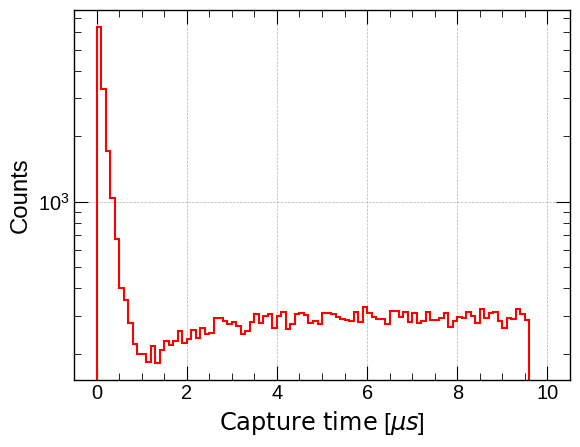

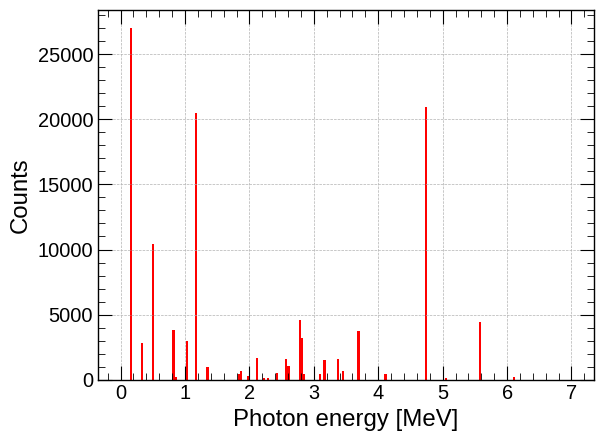

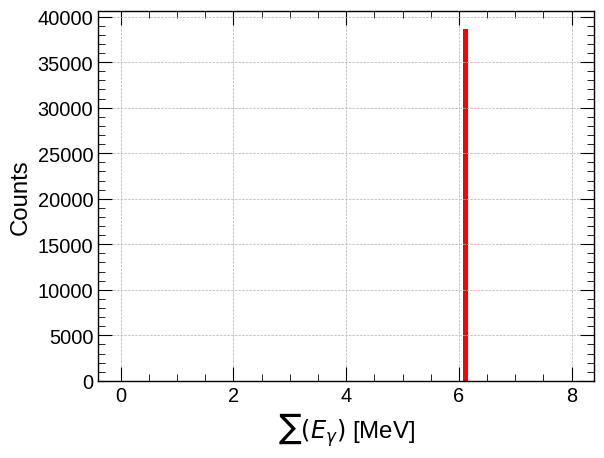

In [36]:
plot_hist(results['capture_times'], bins=100, xlabel=r'$\text{Capture time}$ [$\mu s$]', ylog=True, color='red', hist_kwargs={'range': (0.0, 10.0)})
plot_hist(results['gamma_E'], bins=200, xlabel='Photon energy [MeV]', color='red', histtype='bar', hist_kwargs={'range': (0.0, 7.0)})
plot_hist(results['total_gamma_E'], bins=100, xlabel=r'$\sum(E_{\gamma})$ [MeV]', color='red', histtype='bar', hist_kwargs={'range': (0.0, 8.0)})

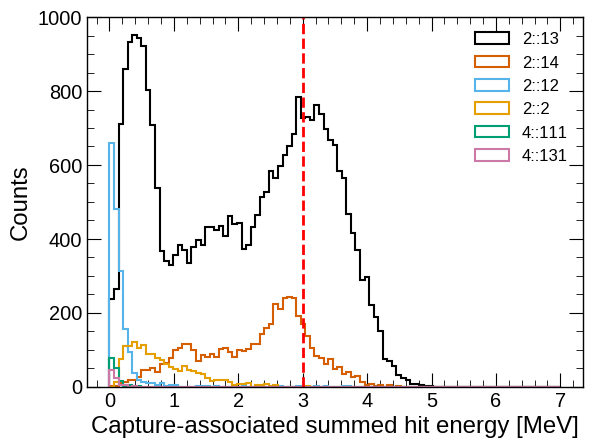

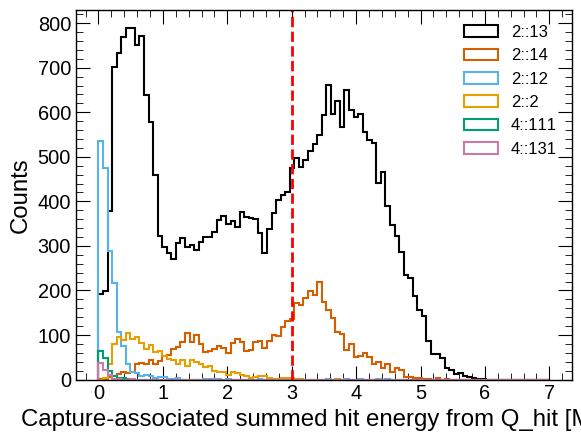

In [37]:
plt.figure()
my_bins = np.linspace(0, 7, 100)
for proc, values in results['E_hit_sum_proc_capture'].items():
    if proc == '-1::-1':
        continue
    plt.hist(values, bins=my_bins, histtype='step', label=proc)
plt.axvline(x=3, ls='--', color='red')
plt.xlabel('Capture-associated summed hit energy [MeV]')
plt.ylabel('Counts')
plt.legend()
plt.show()

plt.figure()
for proc, values in results['E_hit_sum_proc_capture_from_charge'].items():
    if proc == '-1::-1':
        continue
    plt.hist(values, bins=my_bins, histtype='step', label=proc)
plt.axvline(x=3, ls='--', color='red')
plt.xlabel('Capture-associated summed hit energy from Q_hit [MeV]')
plt.ylabel('Counts')
plt.legend()
plt.show()

/tmp/ipykernel_2142832/3218424488.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


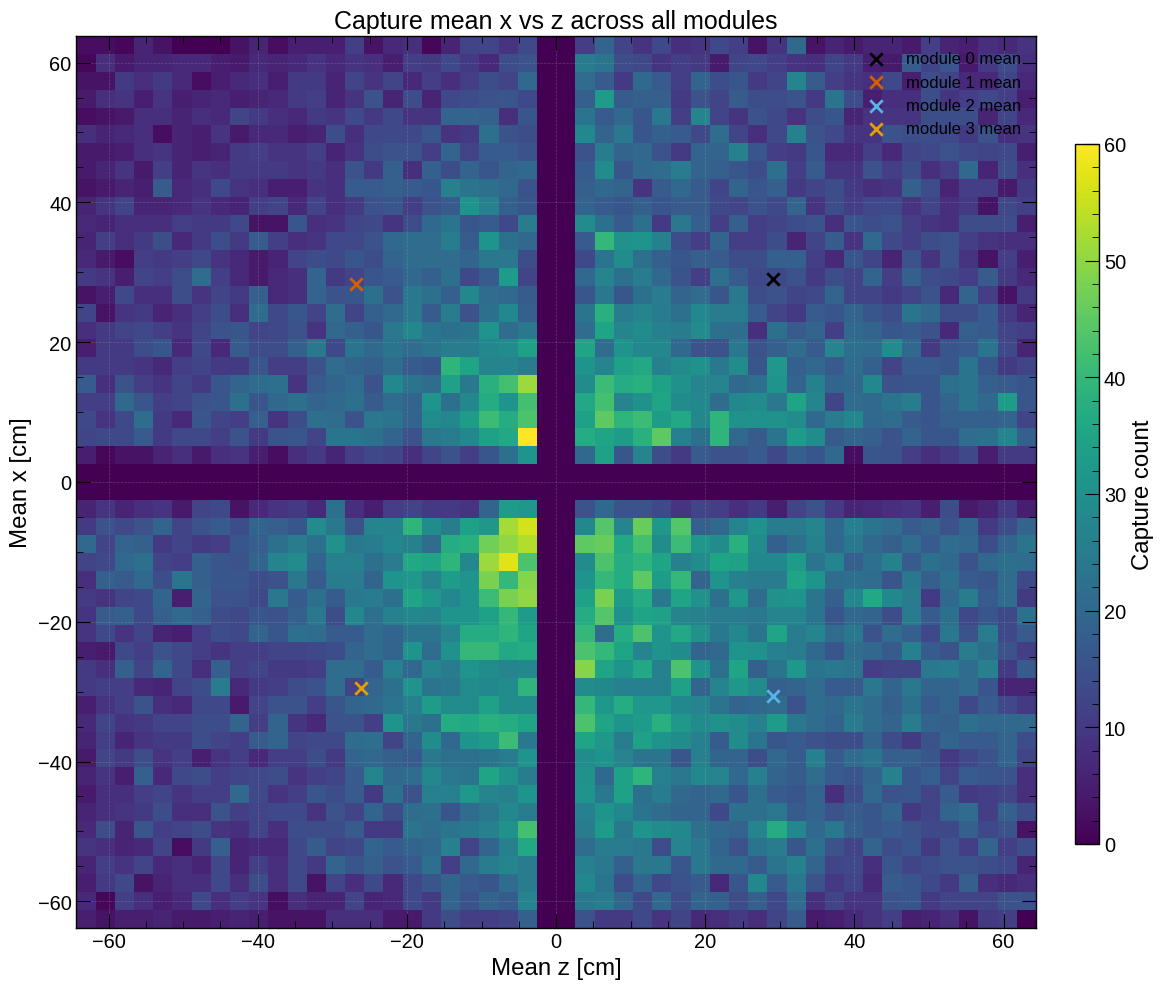

In [38]:
module_map = {
    (0, 0): (0, [1, 2]),
    (1, 0): (1, [3, 4]),
    (0, 1): (2, [5, 6]),
    (1, 1): (3, [7, 8]),
}

module_ids = [module_map[key][0] for key in sorted(module_map.keys())]
all_capture_mean_x = [results['capture_mean_x_module'].get(module_id, np.array([], dtype=np.float64)) for module_id in module_ids]
all_capture_mean_z = [results['capture_mean_z_module'].get(module_id, np.array([], dtype=np.float64)) for module_id in module_ids]
x_values = [values for values in all_capture_mean_x if len(values) > 0]
z_values = [values for values in all_capture_mean_z if len(values) > 0]
if x_values:
    x_min = np.min(np.concatenate(x_values))
    x_max = np.max(np.concatenate(x_values))
    if x_min == x_max:
        x_min -= 0.5
        x_max += 0.5
    x_bins = np.linspace(x_min, x_max, 51)
else:
    x_bins = np.linspace(0.0, 1.0, 51)
if z_values:
    z_min = np.min(np.concatenate(z_values))
    z_max = np.max(np.concatenate(z_values))
    if z_min == z_max:
        z_min -= 0.5
        z_max += 0.5
    z_bins = np.linspace(z_min, z_max, 51)
else:
    z_bins = np.linspace(0.0, 1.0, 51)

fig, ax = plt.subplots(figsize=(12, 10))
hist = None
if x_values and z_values:
    hist = ax.hist2d(np.concatenate(z_values), np.concatenate(x_values), bins=[z_bins, x_bins], cmap='viridis')

for _, (module_id, io_list) in module_map.items():
    x_mean = results['capture_mean_x_module'].get(module_id, np.array([], dtype=np.float64))
    z_mean = results['capture_mean_z_module'].get(module_id, np.array([], dtype=np.float64))
    if len(x_mean) > 0 and len(z_mean) > 0:
        ax.scatter(np.mean(z_mean), np.mean(x_mean), marker='x', s=80, linewidths=2, label=f'module {module_id} mean')

ax.set_title('Capture mean x vs z across all modules', fontsize=18)
ax.set_xlabel('Mean z [cm]')
ax.set_ylabel('Mean x [cm]')
ax.grid(alpha=0.3)
ax.legend(loc='best')

if hist is not None:
    fig.subplots_adjust(right=0.88)
    cax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
    fig.colorbar(hist[3], cax=cax, label='Capture count')
else:
    fig.subplots_adjust(right=0.88)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()


/tmp/ipykernel_2142832/1539045492.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


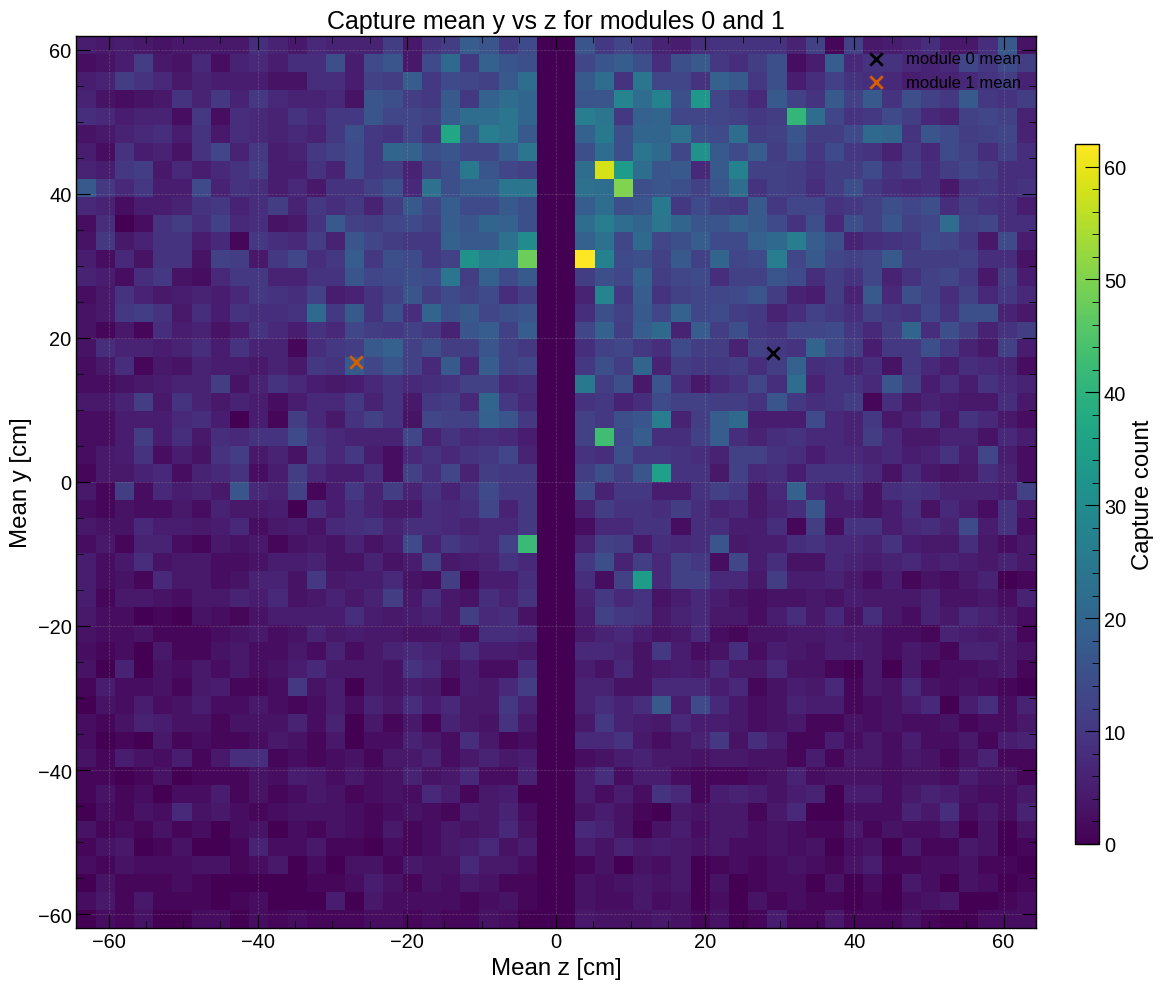

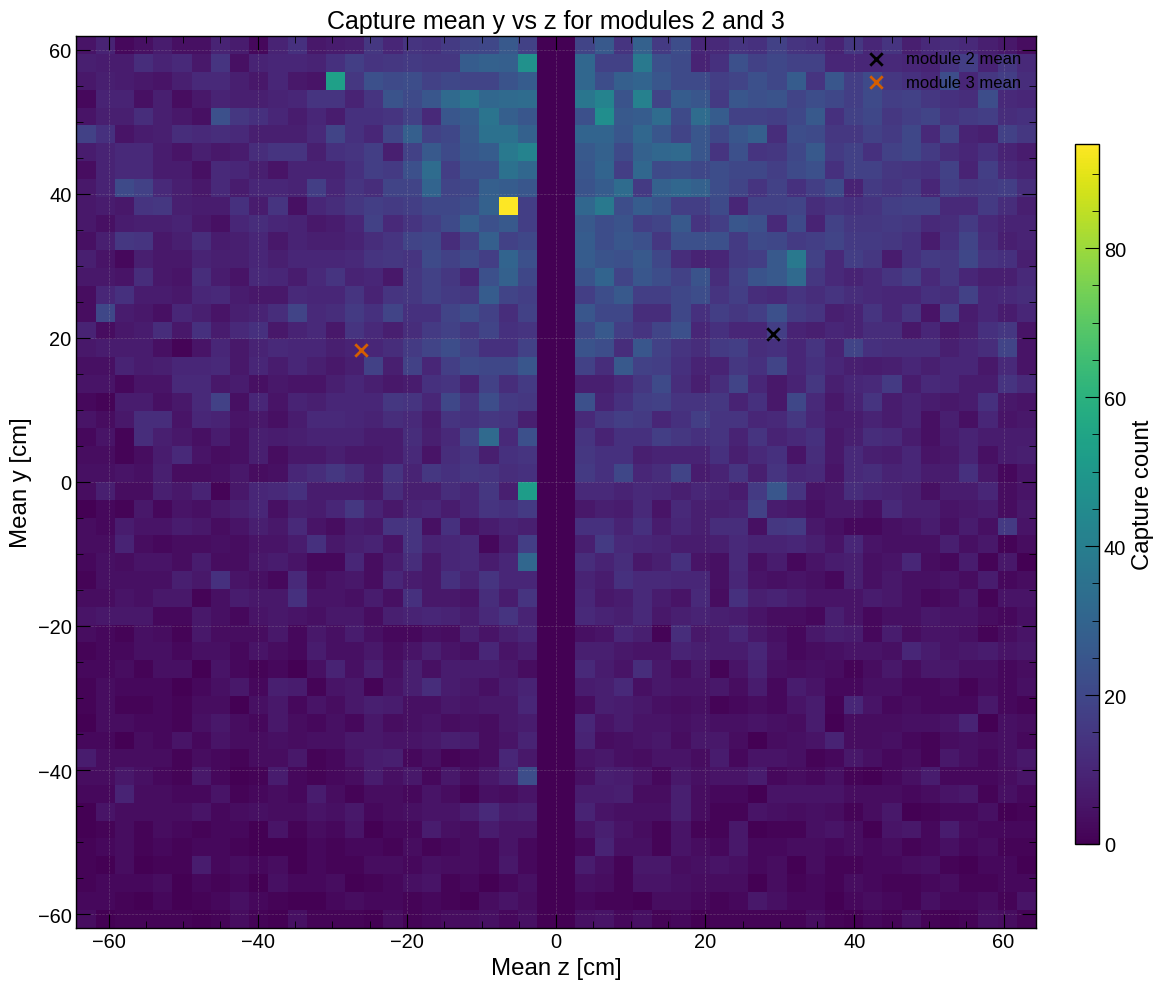

In [39]:
module_map = {
    (0, 0): (0, [1, 2]),
    (1, 0): (1, [3, 4]),
    (0, 1): (2, [5, 6]),
    (1, 1): (3, [7, 8]),
}

module_ids = [module_map[key][0] for key in sorted(module_map.keys())]
all_capture_mean_y = [results['capture_mean_y_module'].get(module_id, np.array([], dtype=np.float64)) for module_id in module_ids]
all_capture_mean_z = [results['capture_mean_z_module'].get(module_id, np.array([], dtype=np.float64)) for module_id in module_ids]
y_values = [values for values in all_capture_mean_y if len(values) > 0]
z_values = [values for values in all_capture_mean_z if len(values) > 0]
if y_values:
    y_min = np.min(np.concatenate(y_values))
    y_max = np.max(np.concatenate(y_values))
    if y_min == y_max:
        y_min -= 0.5
        y_max += 0.5
    y_bins = np.linspace(y_min, y_max, 51)
else:
    y_bins = np.linspace(0.0, 1.0, 51)
if z_values:
    z_min = np.min(np.concatenate(z_values))
    z_max = np.max(np.concatenate(z_values))
    if z_min == z_max:
        z_min -= 0.5
        z_max += 0.5
    z_bins = np.linspace(z_min, z_max, 51)
else:
    z_bins = np.linspace(0.0, 1.0, 51)

module_groups = [
    ([0, 1], 'Capture mean y vs z for modules 0 and 1'),
    ([2, 3], 'Capture mean y vs z for modules 2 and 3'),
]

for group_ids, title in module_groups:
    group_y_values = [results['capture_mean_y_module'].get(module_id, np.array([], dtype=np.float64)) for module_id in group_ids]
    group_z_values = [results['capture_mean_z_module'].get(module_id, np.array([], dtype=np.float64)) for module_id in group_ids]
    group_y_values = [values for values in group_y_values if len(values) > 0]
    group_z_values = [values for values in group_z_values if len(values) > 0]

    fig, ax = plt.subplots(figsize=(12, 10))
    hist = None
    if group_y_values and group_z_values:
        hist = ax.hist2d(np.concatenate(group_z_values), np.concatenate(group_y_values), bins=[z_bins, y_bins], cmap='viridis')

    for module_id in group_ids:
        y_mean = results['capture_mean_y_module'].get(module_id, np.array([], dtype=np.float64))
        z_mean = results['capture_mean_z_module'].get(module_id, np.array([], dtype=np.float64))
        if len(y_mean) > 0 and len(z_mean) > 0:
            ax.scatter(np.mean(z_mean), np.mean(y_mean), marker='x', s=80, linewidths=2, label=f'module {module_id} mean')

    ax.set_title(title, fontsize=18)
    ax.set_xlabel('Mean z [cm]')
    ax.set_ylabel('Mean y [cm]')
    ax.grid(alpha=0.3)
    ax.legend(loc='best')

    if hist is not None:
        fig.subplots_adjust(right=0.88)
        cax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
        fig.colorbar(hist[3], cax=cax, label='Capture count')
    else:
        fig.subplots_adjust(right=0.88)
    plt.tight_layout(rect=[0, 0, 0.88, 1])
    plt.show()


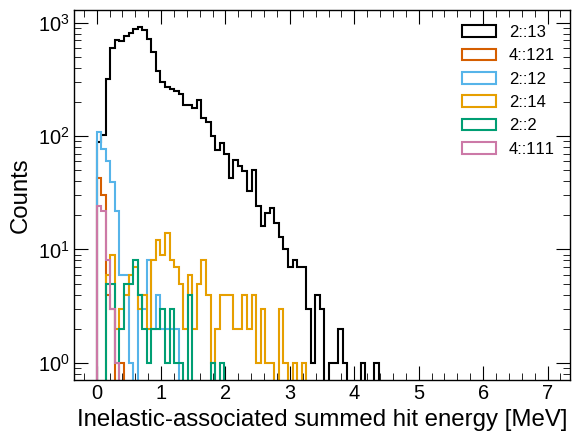

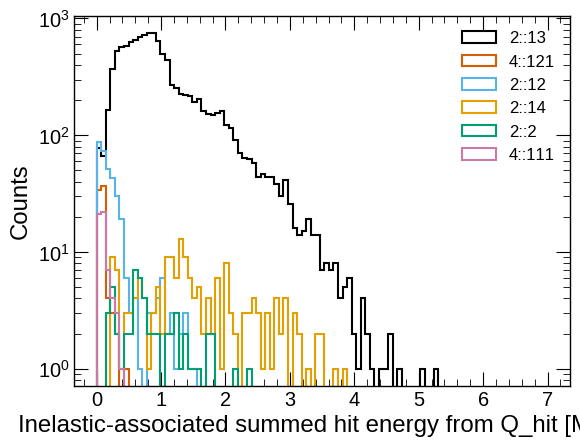

In [40]:
plt.figure()
my_bins = np.linspace(0, 7, 100)
for proc, values in results['E_hit_sum_proc_inelastic'].items():
    if proc == '-1::-1':
        continue
    plt.hist(values, bins=my_bins, histtype='step', label=proc)
plt.yscale('log')
plt.xlabel('Inelastic-associated summed hit energy [MeV]')
plt.ylabel('Counts')
plt.legend()
plt.show()

plt.figure()
for proc, values in results['E_hit_sum_proc_inelastic_from_charge'].items():
    if proc == '-1::-1':
        continue
    plt.hist(values, bins=my_bins, histtype='step', label=proc)
plt.yscale('log')
plt.xlabel('Inelastic-associated summed hit energy from Q_hit [MeV]')
plt.ylabel('Counts')
plt.legend()
plt.show()

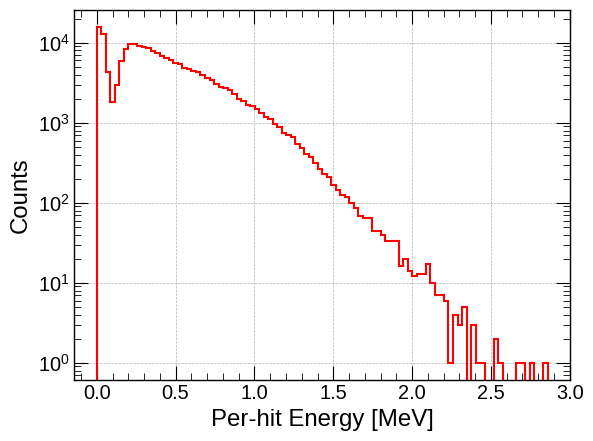

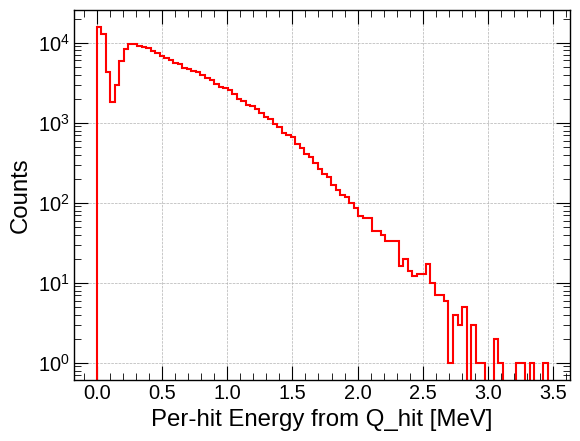

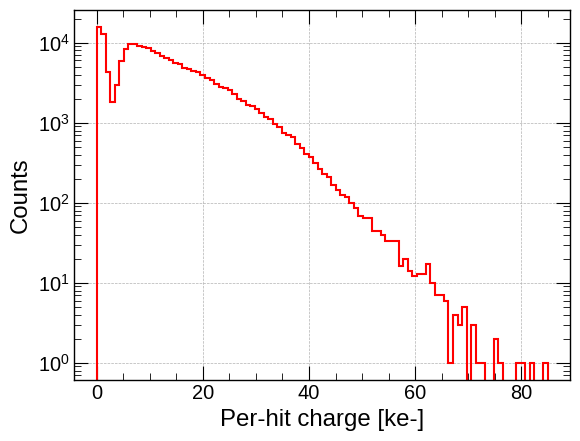

In [41]:
plot_hist(results['E_hits'], bins=100, xlabel='Per-hit Energy [MeV]', ylog=True)
plot_hist(charge_to_energy_mev(results['Q_hits']), bins=100, xlabel='Per-hit Energy from Q_hit [MeV]', ylog=True)
plot_hist(results['Q_hits'], bins=100, xlabel='Per-hit charge [ke-]', ylog=True)

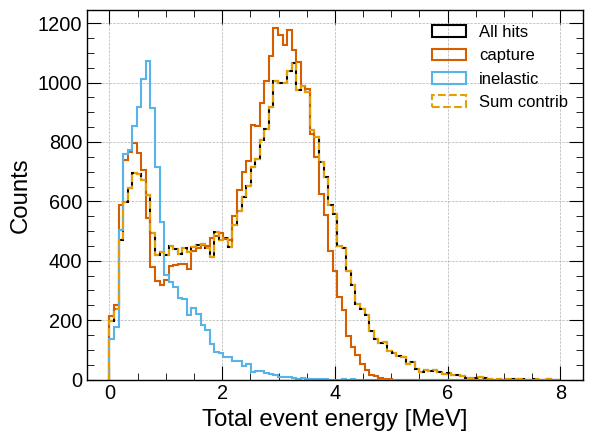

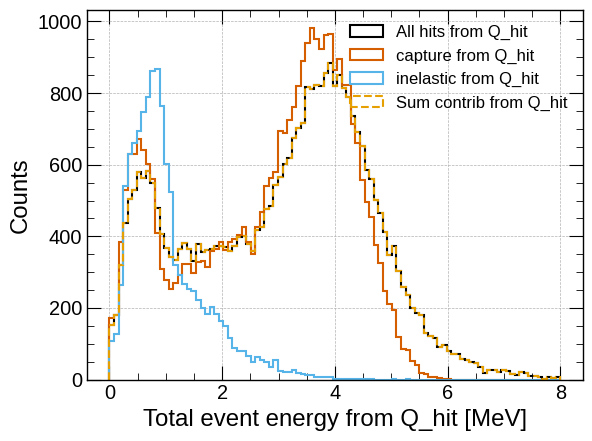

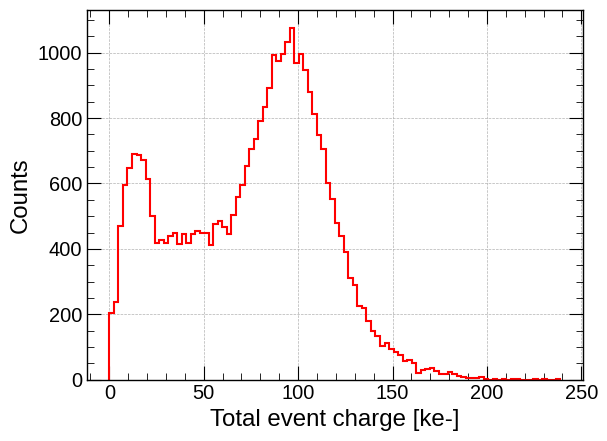

In [42]:
my_binning = np.linspace(0, 8, 100)

plt.figure()
plt.hist(results['E_sum_hits'], bins=my_binning, histtype='step', label='All hits')
plt.hist(results['E_sum_capture'], bins=my_binning, histtype='step', label='capture')
plt.hist(results['E_sum_inelastic'], bins=my_binning, histtype='step', label='inelastic')
plt.hist(results['E_sum_total'], bins=my_binning, histtype='step', label='Sum contrib', ls='--')
plt.xlabel('Total event energy [MeV]')
plt.ylabel('Counts')
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.hist(results['E_sum_hits_from_charge'], bins=my_binning, histtype='step', label='All hits from Q_hit')
plt.hist(results['E_sum_capture_from_charge'], bins=my_binning, histtype='step', label='capture from Q_hit')
plt.hist(results['E_sum_inelastic_from_charge'], bins=my_binning, histtype='step', label='inelastic from Q_hit')
plt.hist(results['E_sum_total_from_charge'], bins=my_binning, histtype='step', label='Sum contrib from Q_hit', ls='--')
plt.xlabel('Total event energy from Q_hit [MeV]')
plt.ylabel('Counts')
plt.legend()
plt.grid()
plt.show()

plot_hist(results['Q_sum_hits'], bins=100, xlabel='Total event charge [ke-]')

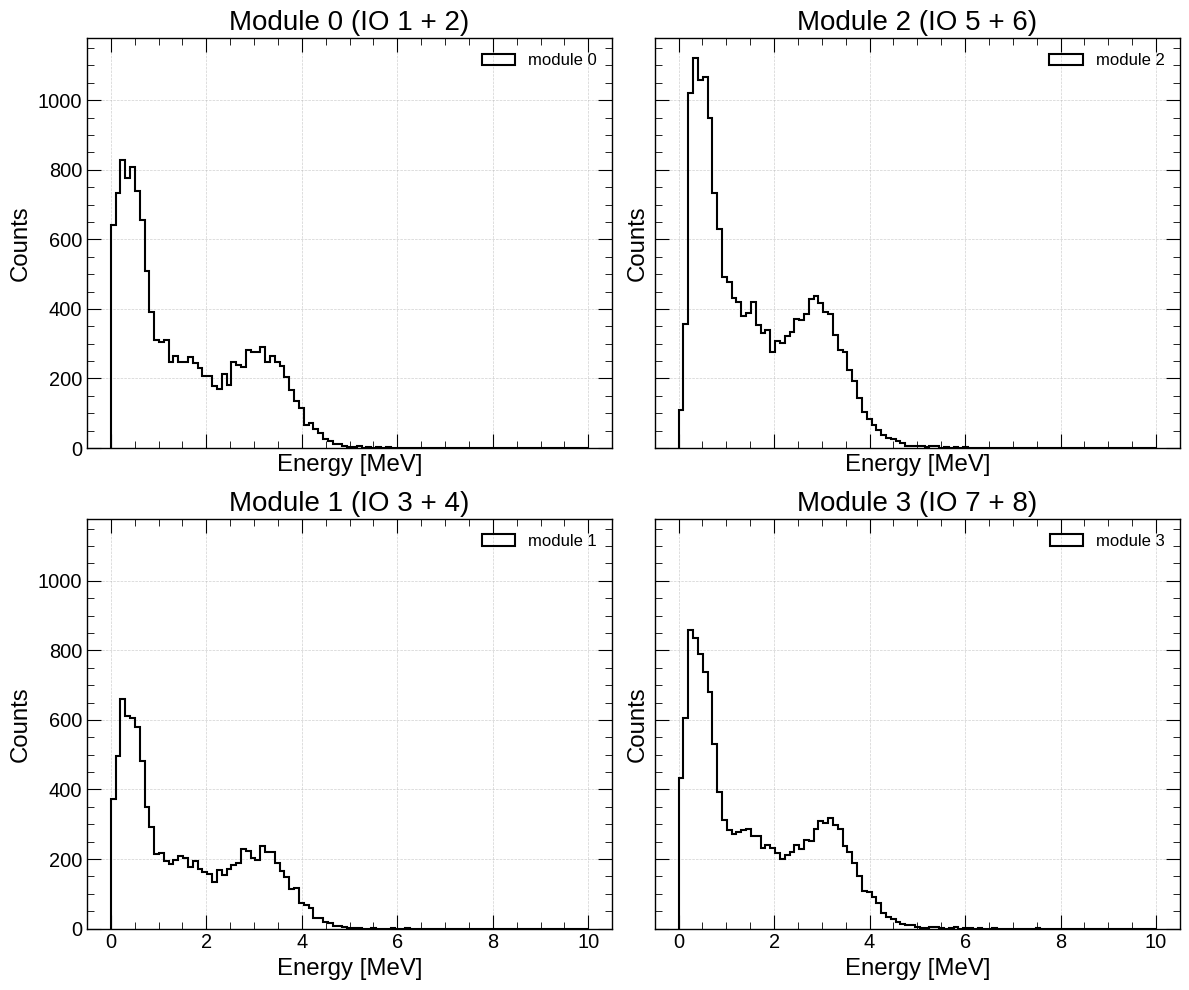

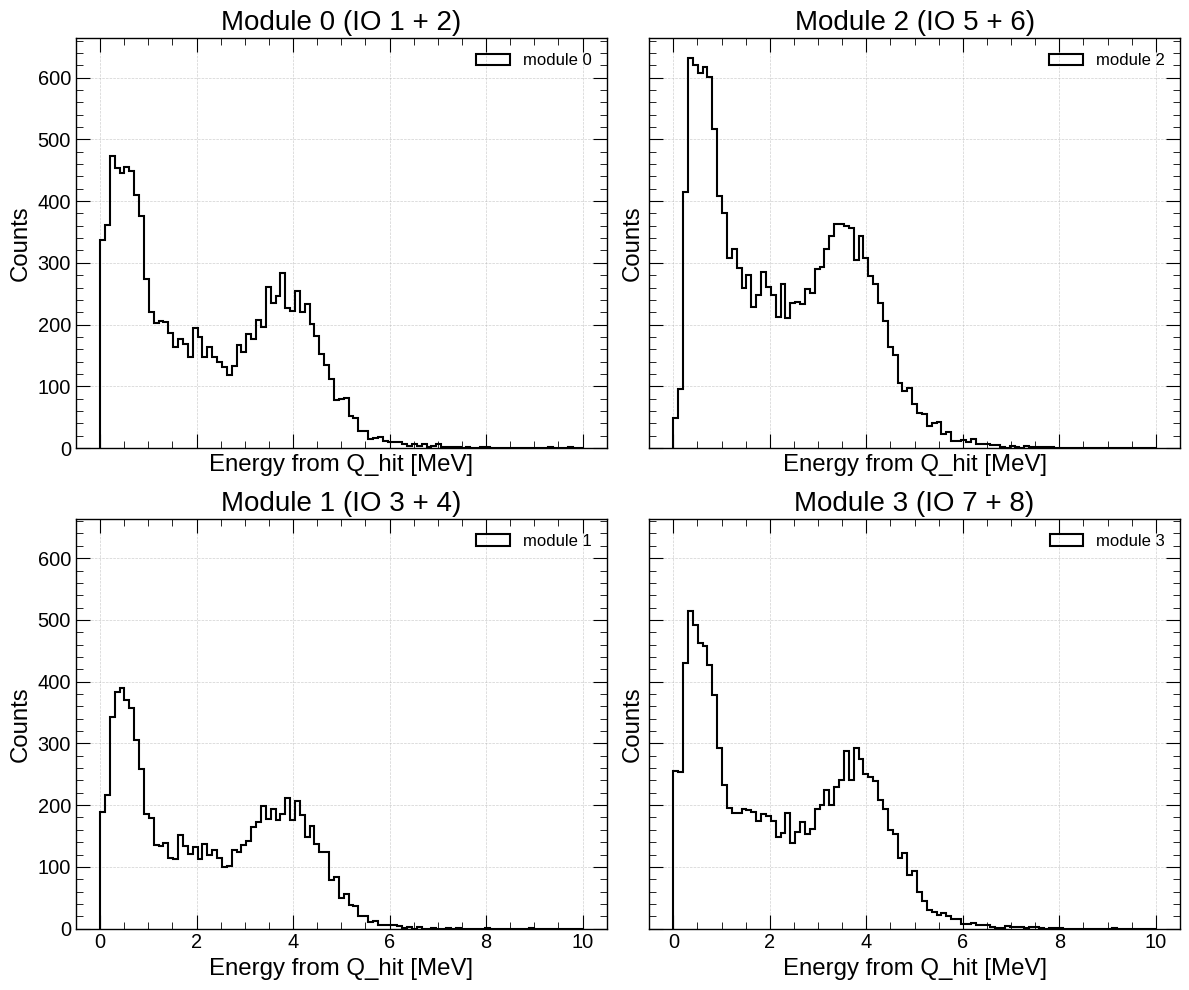

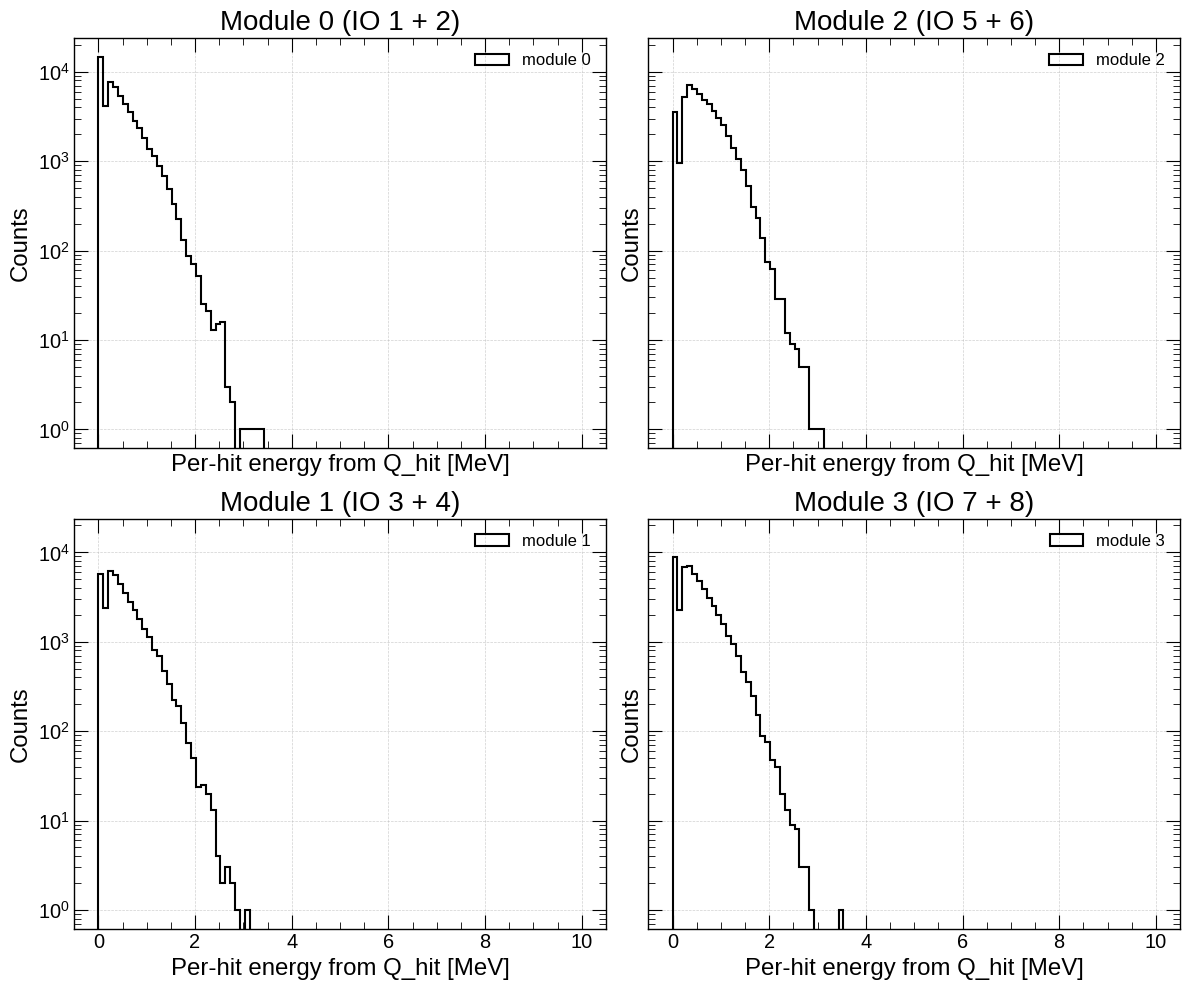

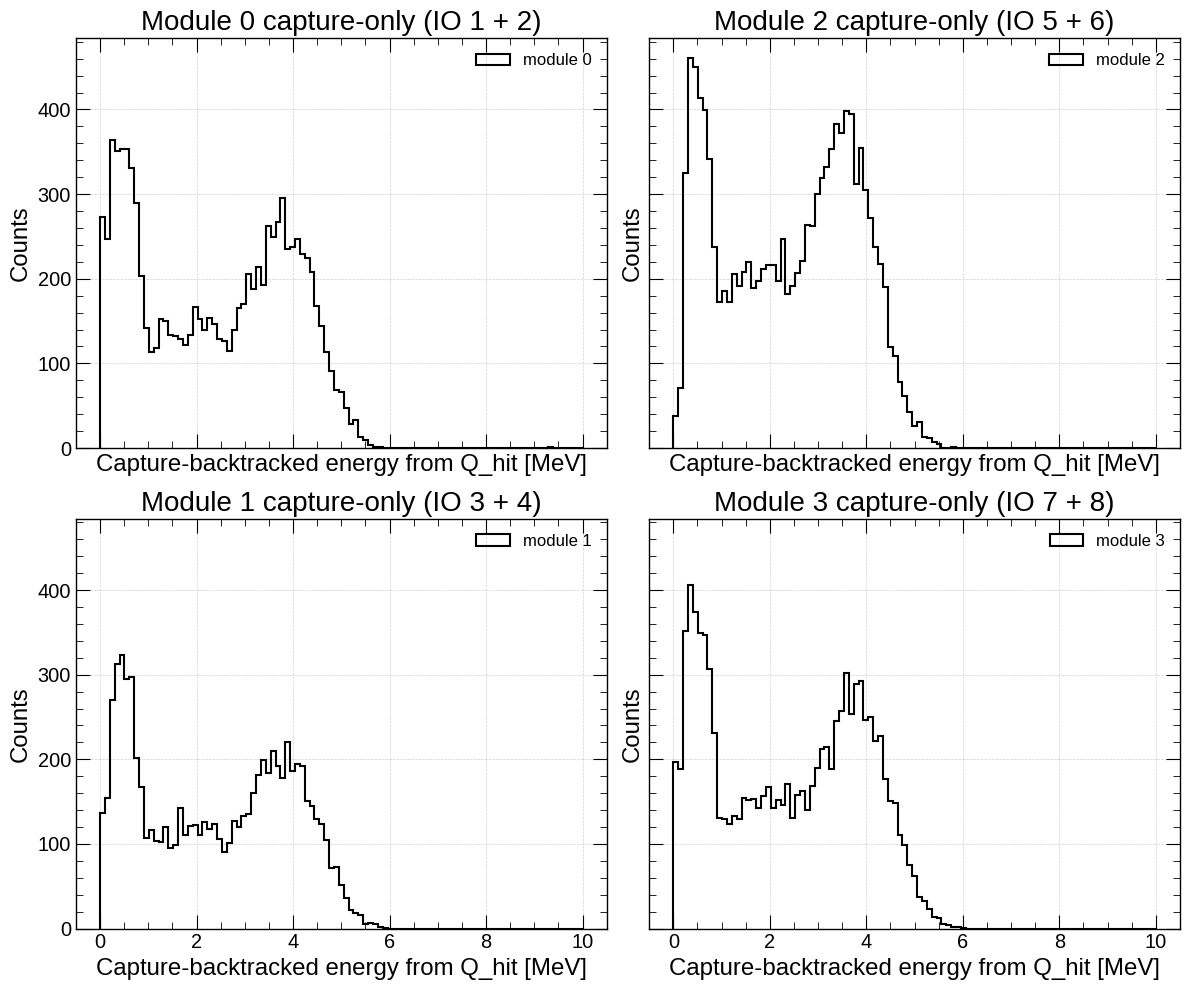

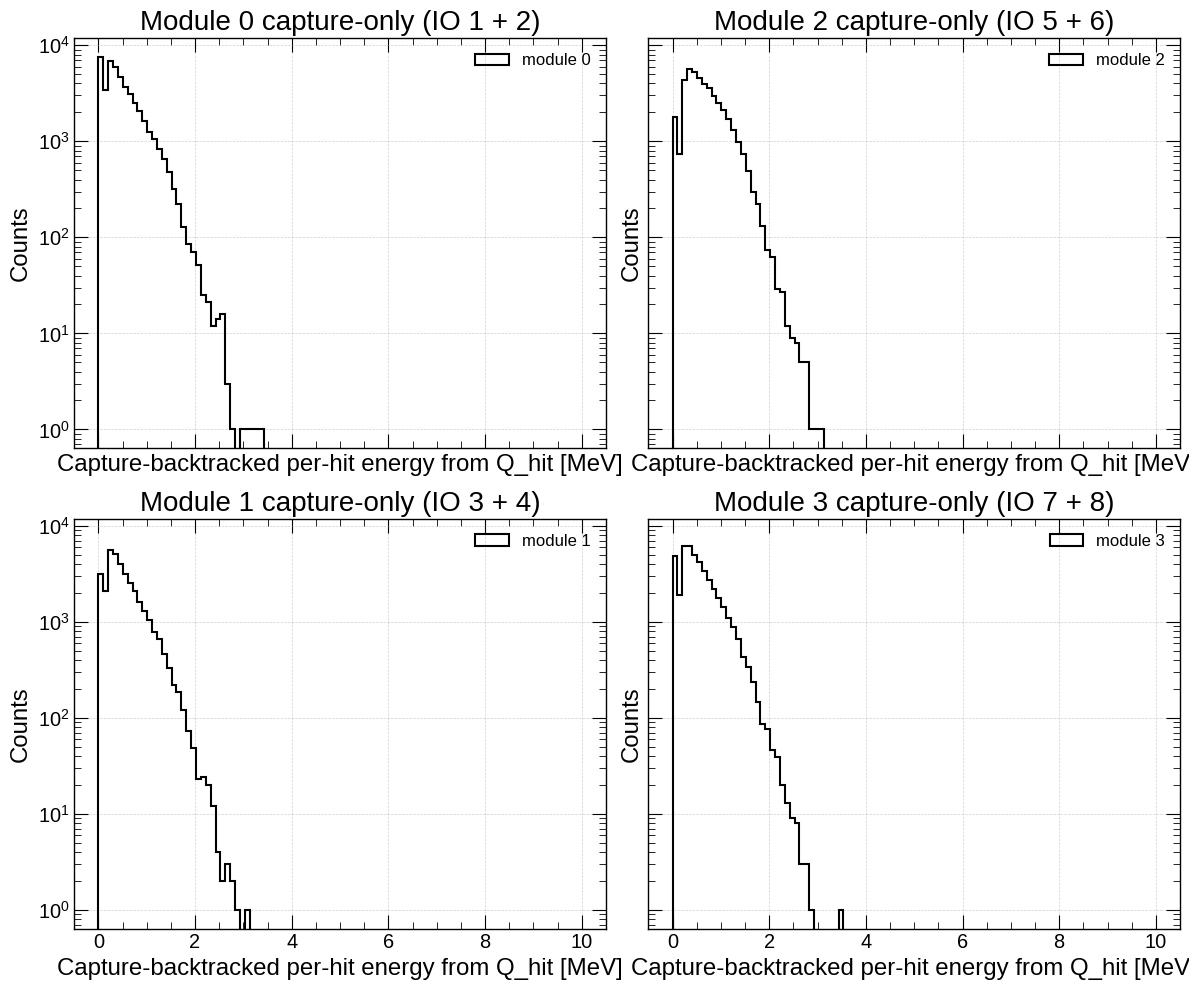

In [43]:
module_map = {
    (0, 0): (0, [1, 2]),
    (1, 0): (1, [3, 4]),
    (0, 1): (2, [5, 6]),
    (1, 1): (3, [7, 8]),
}

bins = np.linspace(0, 10.0, 100)
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for (row, col), (module_id, io_list) in module_map.items():
    ax = axes[row, col]
    detector_samples = [results['E_cluster_io'][io_val] for io_val in io_list if io_val in results['E_cluster_io']]
    if detector_samples:
        detector_values = np.concatenate(detector_samples)
        ax.hist(detector_values, bins=bins, histtype='step', label=f'module {module_id}')
        ax.legend()
    ax.set_title(f'Module {module_id} (IO {io_list[0]} + {io_list[1]})', fontsize=20)
    ax.set_xlabel('Energy [MeV]')
    ax.set_ylabel('Counts')
    ax.grid(alpha=0.6)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for (row, col), (module_id, io_list) in module_map.items():
    ax = axes[row, col]
    module_values = results['Q_event_module'].get(module_id, np.array([], dtype=np.float64))
    if len(module_values) > 0:
        ax.hist(charge_to_energy_mev(module_values), bins=bins, histtype='step', label=f'module {module_id}')
        ax.legend()
    ax.set_title(f'Module {module_id} (IO {io_list[0]} + {io_list[1]})', fontsize=20)
    ax.set_xlabel('Energy from Q_hit [MeV]')
    ax.set_ylabel('Counts')
    ax.grid(alpha=0.6)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for (row, col), (module_id, io_list) in module_map.items():
    ax = axes[row, col]
    detector_samples = [charge_to_energy_mev(results['Q_hits_io'][io_val]) for io_val in io_list if io_val in results['Q_hits_io']]
    detector_samples = [values for values in detector_samples if len(values) > 0]
    if detector_samples:
        detector_values = np.concatenate(detector_samples)
        ax.hist(detector_values, bins=bins, histtype='step', label=f'module {module_id}')
        ax.legend()
    ax.set_title(f'Module {module_id} (IO {io_list[0]} + {io_list[1]})', fontsize=20)
    ax.set_yscale('log')
    ax.set_xlabel('Per-hit energy from Q_hit [MeV]')
    ax.set_ylabel('Counts')
    ax.grid(alpha=0.6)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for (row, col), (module_id, io_list) in module_map.items():
    ax = axes[row, col]
    module_values = results['Q_event_module_capture'].get(module_id, np.array([], dtype=np.float64))
    if len(module_values) > 0:
        ax.hist(charge_to_energy_mev(module_values), bins=bins, histtype='step', label=f'module {module_id}')
        ax.legend()
    ax.set_title(f'Module {module_id} capture-only (IO {io_list[0]} + {io_list[1]})', fontsize=20)
    ax.set_xlabel('Capture-backtracked energy from Q_hit [MeV]')
    ax.set_ylabel('Counts')
    ax.grid(alpha=0.6)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for (row, col), (module_id, io_list) in module_map.items():
    ax = axes[row, col]
    detector_samples = [charge_to_energy_mev(results['Q_hits_io_capture'][io_val]) for io_val in io_list if io_val in results['Q_hits_io_capture']]
    detector_samples = [values for values in detector_samples if len(values) > 0]
    if detector_samples:
        detector_values = np.concatenate(detector_samples)
        ax.hist(detector_values, bins=bins, histtype='step', label=f'module {module_id}')
        ax.legend()
    ax.set_title(f'Module {module_id} capture-only (IO {io_list[0]} + {io_list[1]})', fontsize=20)
    ax.set_yscale('log')
    ax.set_xlabel('Capture-backtracked per-hit energy from Q_hit [MeV]')
    ax.set_ylabel('Counts')
    ax.grid(alpha=0.6)
plt.tight_layout()
plt.show()

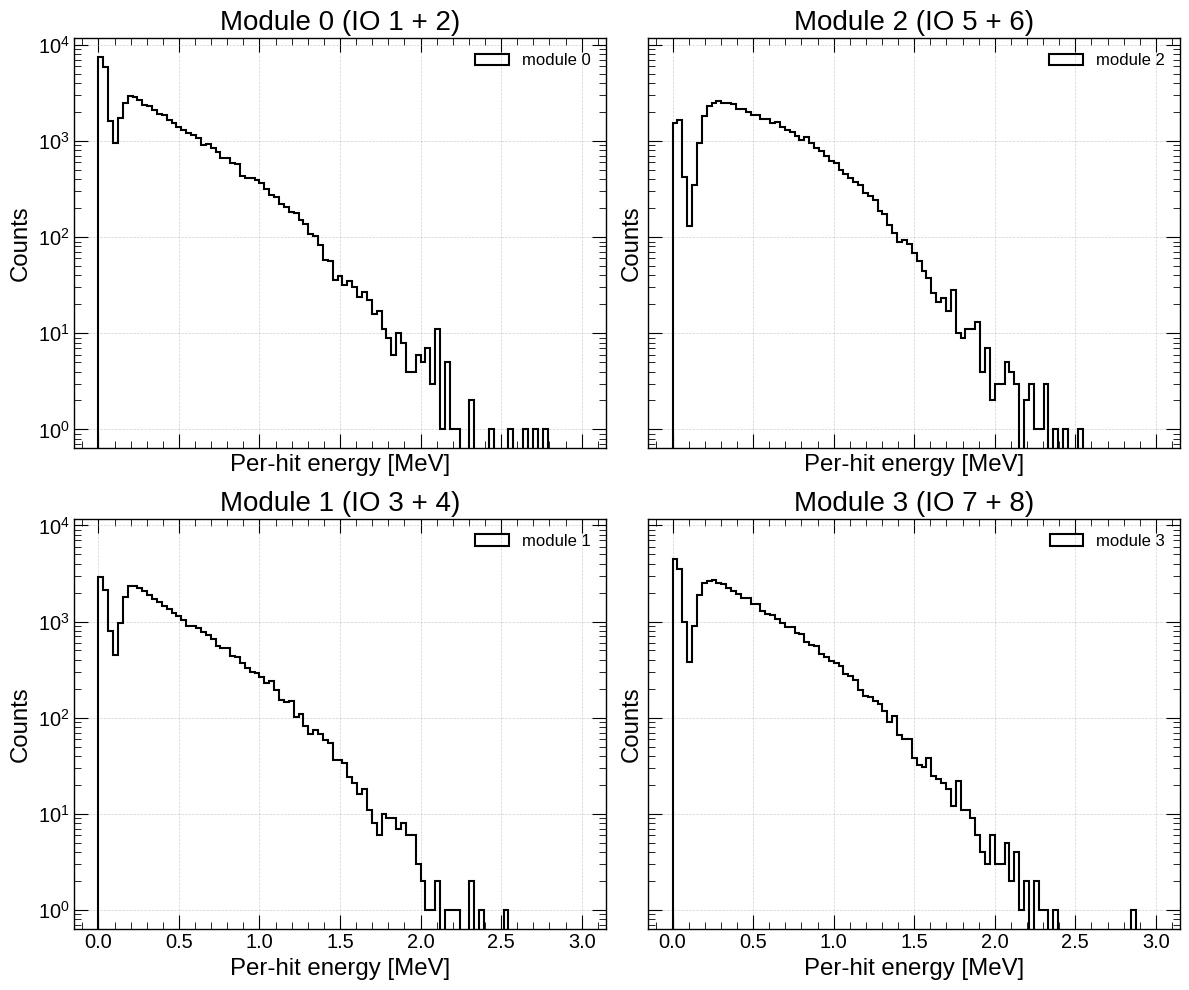

In [44]:
bins = np.linspace(0, 3.0, 100)
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for (row, col), (module_id, io_list) in module_map.items():
    ax = axes[row, col]
    detector_samples = [results['E_hits_io'][io_val] for io_val in io_list if io_val in results['E_hits_io']]
    if detector_samples:
        detector_values = np.concatenate(detector_samples)
        ax.hist(detector_values, bins=bins, histtype='step', label=f'module {module_id}')
        ax.legend()
    ax.set_title(f'Module {module_id} (IO {io_list[0]} + {io_list[1]})', fontsize=20)
    ax.set_yscale('log')
    ax.set_xlabel('Per-hit energy [MeV]')
    ax.set_ylabel('Counts')
    ax.grid(alpha=0.6)
plt.tight_layout()
plt.show()

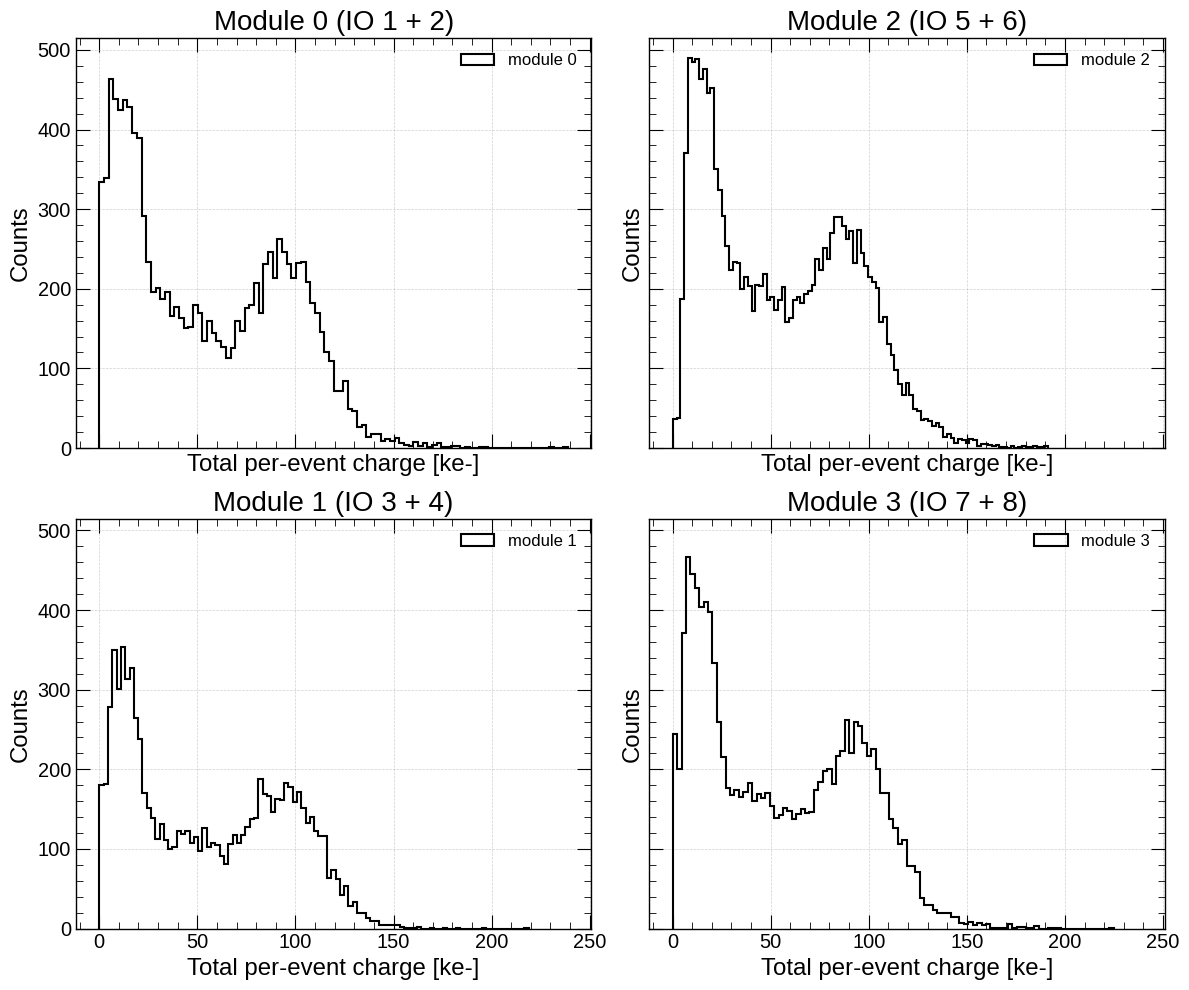

In [45]:
bins = 100
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for (row, col), (module_id, io_list) in module_map.items():
    ax = axes[row, col]
    module_values = results['Q_event_module'].get(module_id, np.array([], dtype=np.float64))
    if len(module_values) > 0:
        ax.hist(module_values, bins=bins, histtype='step', label=f'module {module_id}')
        ax.legend()
    ax.set_title(f'Module {module_id} (IO {io_list[0]} + {io_list[1]})', fontsize=20)
    ax.set_xlabel('Total per-event charge [ke-]')
    ax.set_ylabel('Counts')
    ax.grid(alpha=0.6)
plt.tight_layout()
plt.show()

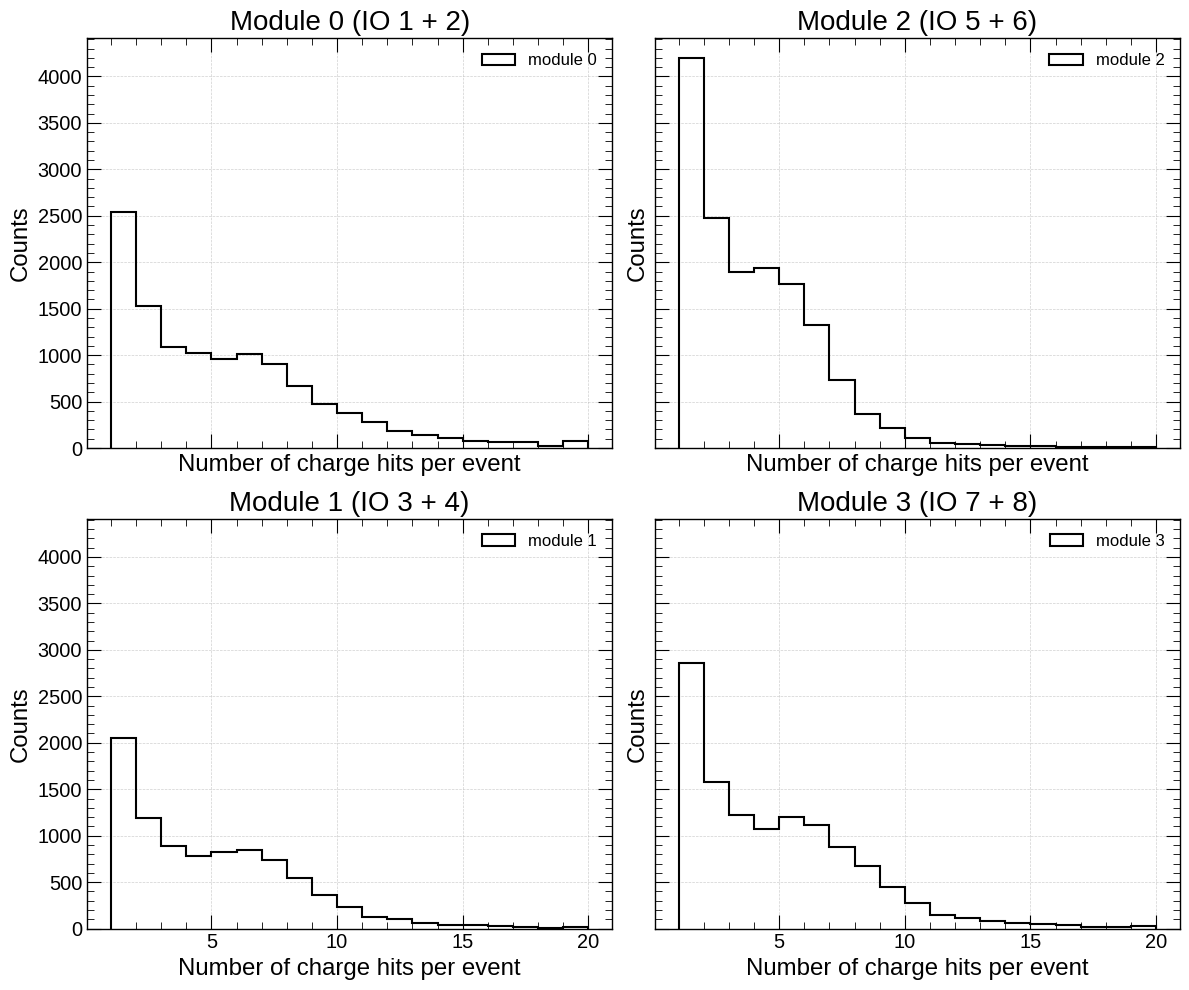

In [46]:
max_hits = max((values.max() for values in results['n_hits_module'].values() if len(values) > 0), default=0)
bins = np.linspace(1,20,20)
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for (row, col), (module_id, io_list) in module_map.items():
    ax = axes[row, col]
    module_values = results['n_hits_module'].get(module_id, np.array([], dtype=np.int64))
    if len(module_values) > 0:
        ax.hist(module_values, bins=bins, histtype='step', label=f'module {module_id}')
        ax.legend()
    ax.set_title(f'Module {module_id} (IO {io_list[0]} + {io_list[1]})', fontsize=20)
    ax.set_xlabel('Number of charge hits per event')
    ax.set_ylabel('Counts')
    ax.grid(alpha=0.6)
plt.tight_layout()
plt.show()

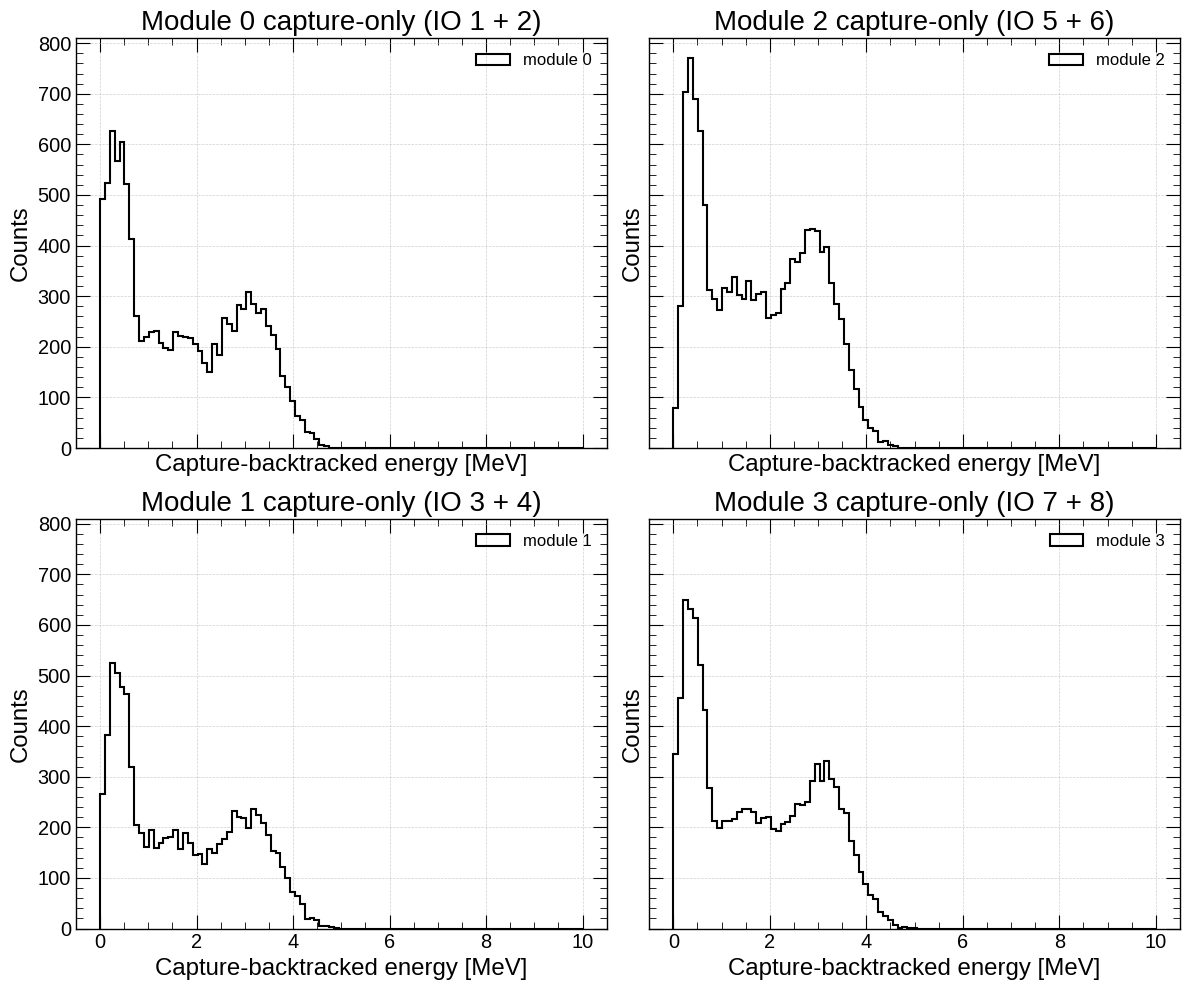

In [47]:
bins = np.linspace(0, 10.0, 100)
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for (row, col), (module_id, io_list) in module_map.items():
    ax = axes[row, col]
    detector_samples = [results['E_cluster_io_capture'][io_val] for io_val in io_list if io_val in results['E_cluster_io_capture']]
    if detector_samples:
        detector_values = np.concatenate(detector_samples)
        ax.hist(detector_values, bins=bins, histtype='step', label=f'module {module_id}')
        ax.legend()
    ax.set_title(f'Module {module_id} capture-only (IO {io_list[0]} + {io_list[1]})', fontsize=20)
    ax.set_xlabel('Capture-backtracked energy [MeV]')
    ax.set_ylabel('Counts')
    ax.grid(alpha=0.6)
plt.tight_layout()
plt.show()

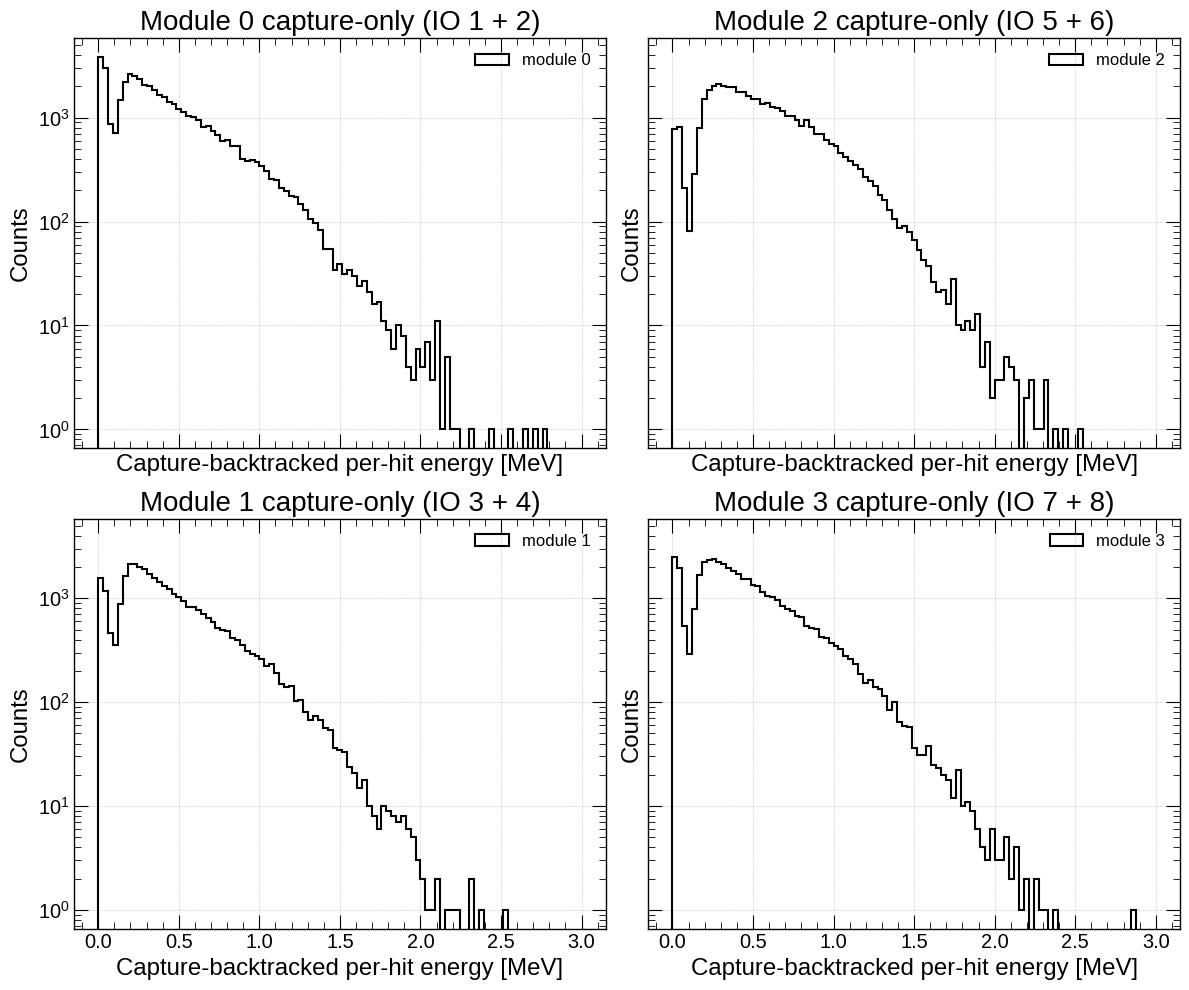

In [48]:
bins = np.linspace(0, 3.0, 100)
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for (row, col), (module_id, io_list) in module_map.items():
    ax = axes[row, col]
    detector_samples = [results['E_hits_io_capture'][io_val] for io_val in io_list if io_val in results['E_hits_io_capture']]
    if detector_samples:
        detector_values = np.concatenate(detector_samples)
        ax.hist(detector_values, bins=bins, histtype='step', label=f'module {module_id}')
        ax.legend()
    ax.set_title(f'Module {module_id} capture-only (IO {io_list[0]} + {io_list[1]})', fontsize=20)
    ax.set_yscale('log')
    ax.set_xlabel('Capture-backtracked per-hit energy [MeV]')
    ax.set_ylabel('Counts')
    ax.grid(alpha=0.6)
plt.tight_layout()
plt.show()

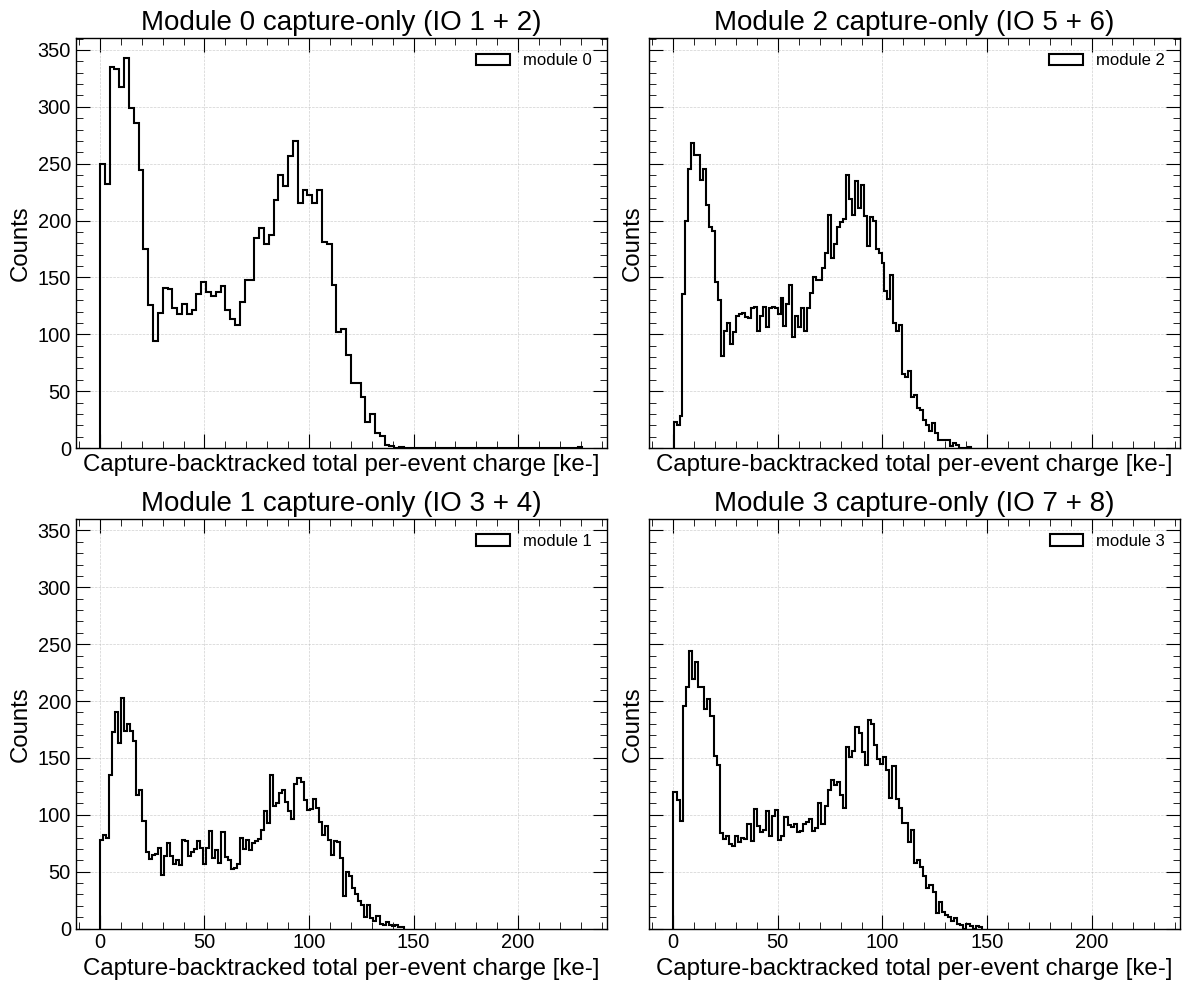

In [49]:
bins = 100
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for (row, col), (module_id, io_list) in module_map.items():
    ax = axes[row, col]
    module_values = results['Q_event_module_capture'].get(module_id, np.array([], dtype=np.float64))
    if len(module_values) > 0:
        ax.hist(module_values, bins=bins, histtype='step', label=f'module {module_id}')
        ax.legend()
    ax.set_title(f'Module {module_id} capture-only (IO {io_list[0]} + {io_list[1]})', fontsize=20)
    ax.set_xlabel('Capture-backtracked total per-event charge [ke-]')
    ax.set_ylabel('Counts')
    ax.grid(alpha=0.6)
plt.tight_layout()
plt.show()

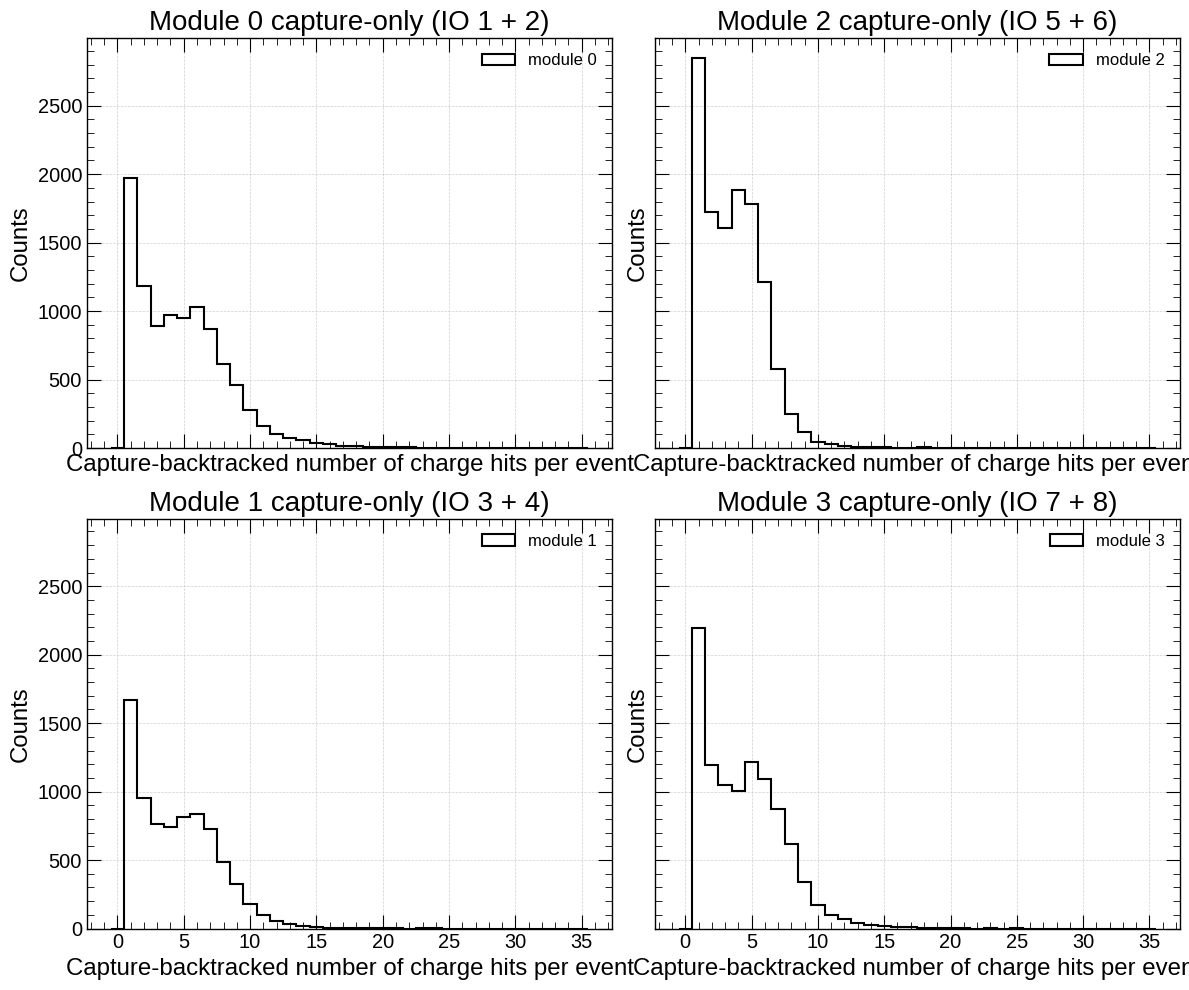

In [50]:
max_hits = max((values.max() for values in results['n_hits_module_capture'].values() if len(values) > 0), default=0)
bins = np.arange(0, max_hits + 2) - 0.5
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for (row, col), (module_id, io_list) in module_map.items():
    ax = axes[row, col]
    module_values = results['n_hits_module_capture'].get(module_id, np.array([], dtype=np.int64))
    if len(module_values) > 0:
        ax.hist(module_values, bins=bins, histtype='step', label=f'module {module_id}')
        ax.legend()
    ax.set_title(f'Module {module_id} capture-only (IO {io_list[0]} + {io_list[1]})', fontsize=20)
    ax.set_xlabel('Capture-backtracked number of charge hits per event')
    ax.set_ylabel('Counts')
    ax.grid(alpha=0.6)
plt.tight_layout()
plt.show()

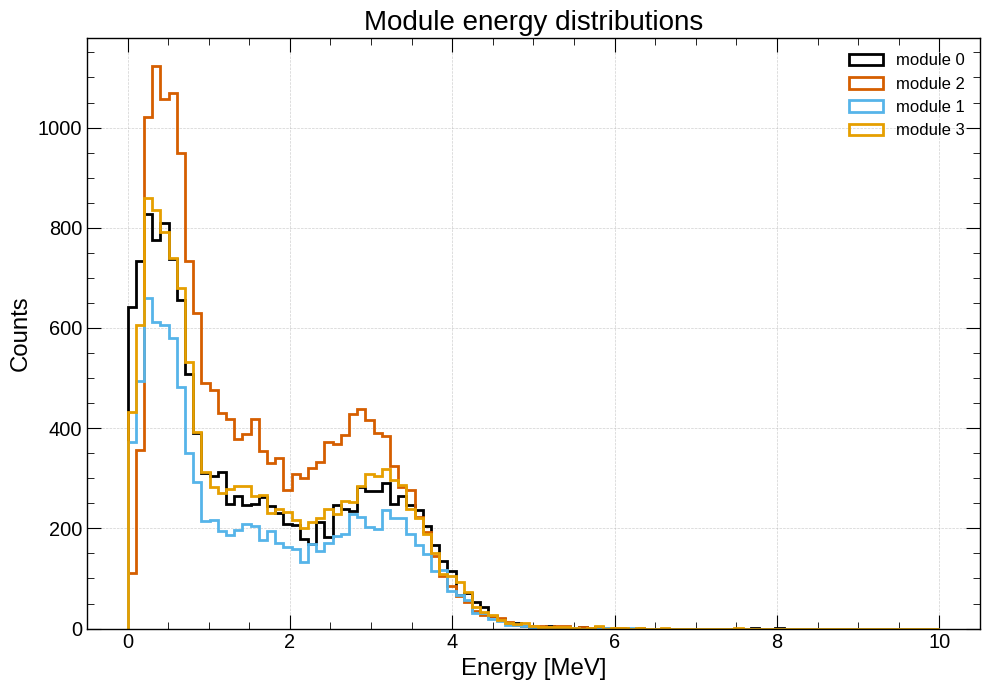

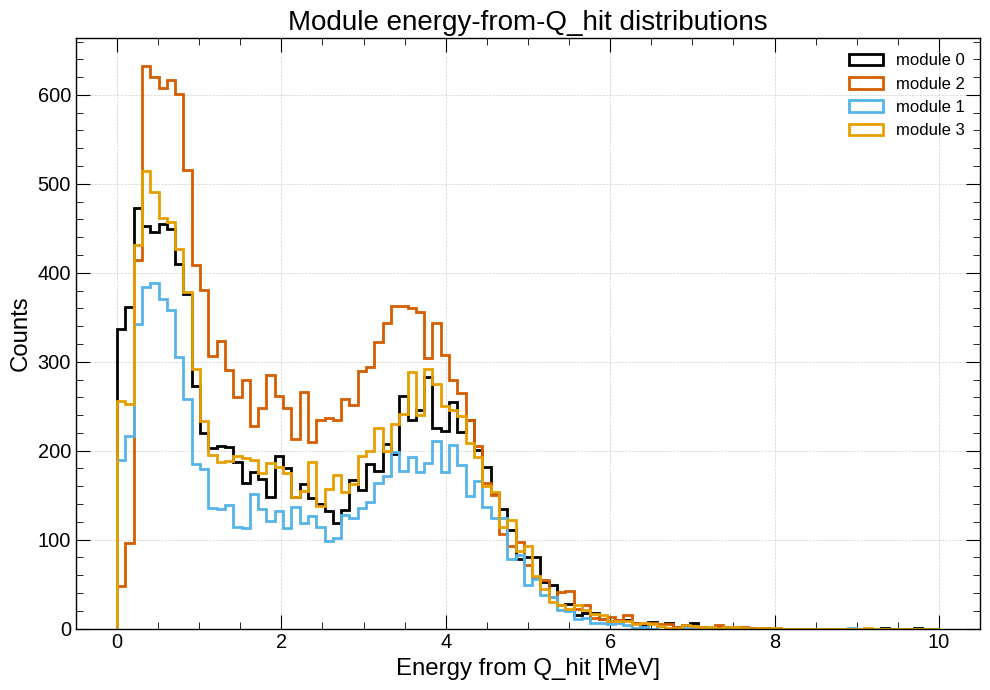

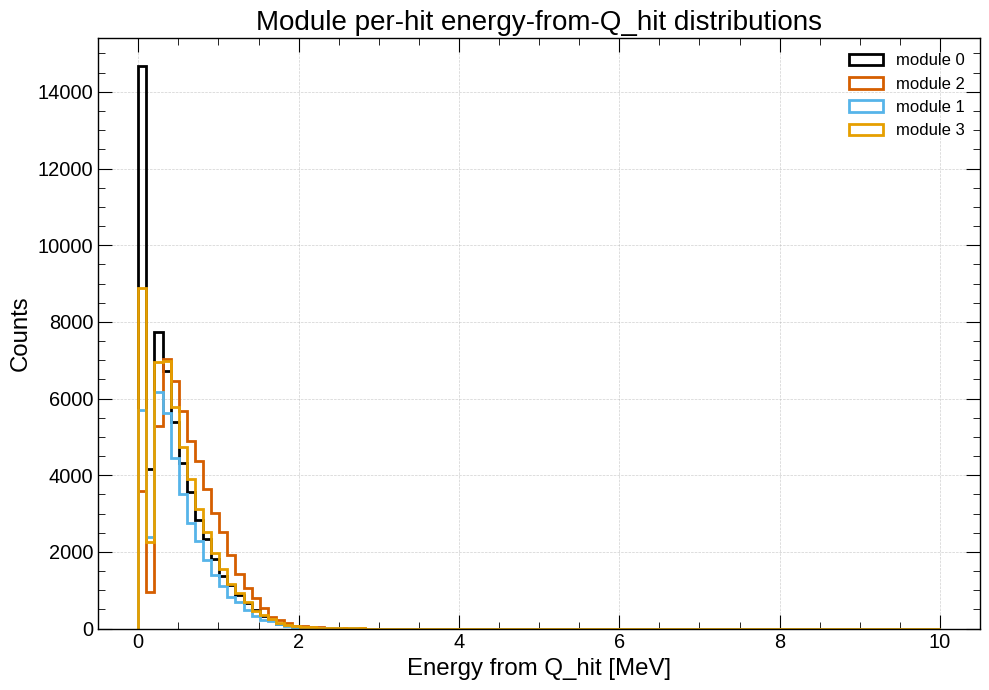

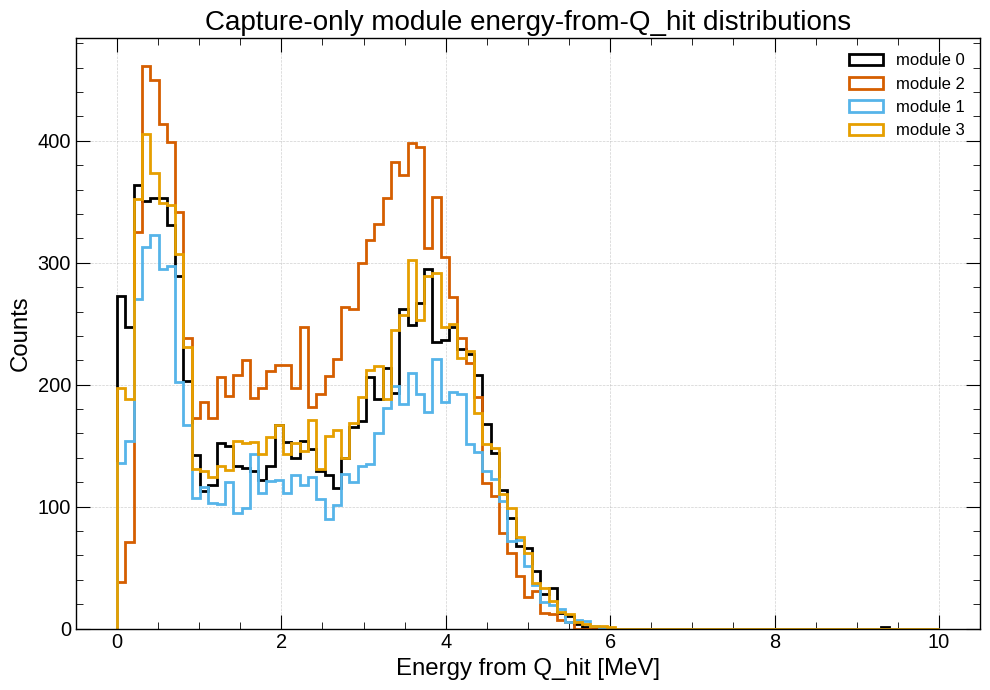

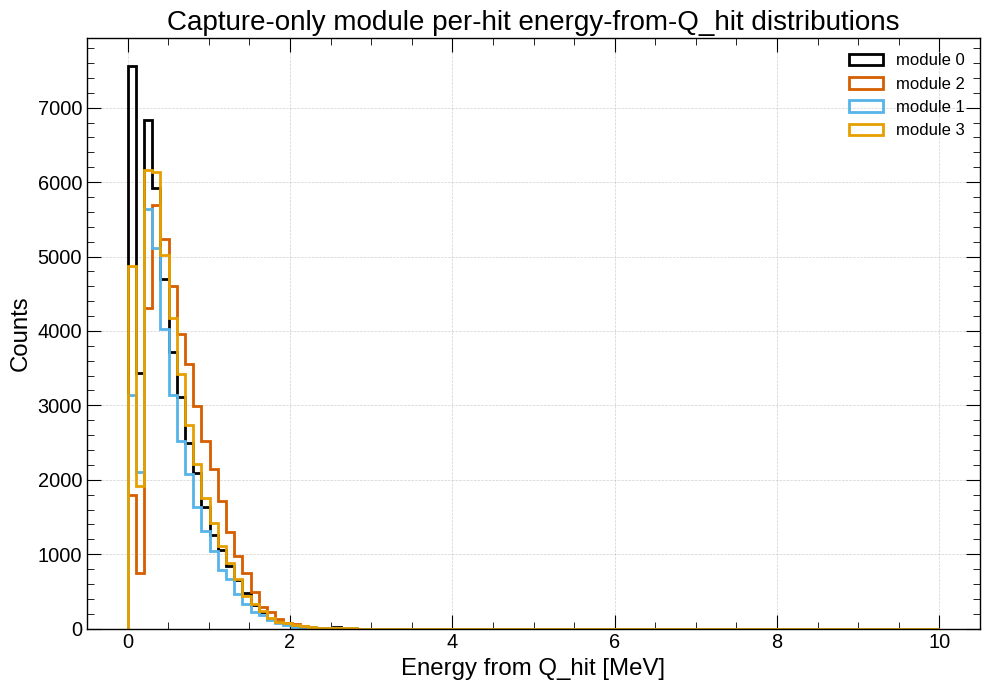

In [51]:
bins = np.linspace(0, 10.0, 100)
plt.figure(figsize=(10, 7))
for module_id, io_list in [module_map[key] for key in sorted(module_map.keys())]:
    detector_samples = [results['E_cluster_io'][io_val] for io_val in io_list if io_val in results['E_cluster_io']]
    if detector_samples:
        detector_values = np.concatenate(detector_samples)
        plt.hist(detector_values, bins=bins, histtype='step', linewidth=2, label=f'module {module_id}')

plt.xlabel('Energy [MeV]')
plt.ylabel('Counts')
plt.title('Module energy distributions')
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()

bins = np.linspace(0, 10.0, 100)
plt.figure(figsize=(10, 7))
for module_id, _ in [module_map[key] for key in sorted(module_map.keys())]:
    q_values = results['Q_event_module'].get(module_id, np.array([], dtype=np.float64))
    if len(q_values) > 0:
        plt.hist(charge_to_energy_mev(q_values), bins=bins, histtype='step', linewidth=2, label=f'module {module_id}')

plt.xlabel('Energy from Q_hit [MeV]')
plt.ylabel('Counts')
plt.title('Module energy-from-Q_hit distributions')
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()

bins = np.linspace(0, 10.0, 100)
plt.figure(figsize=(10, 7))
for module_id, io_list in [module_map[key] for key in sorted(module_map.keys())]:
    detector_samples = [charge_to_energy_mev(results['Q_hits_io'][io_val]) for io_val in io_list if io_val in results['Q_hits_io']]
    detector_samples = [values for values in detector_samples if len(values) > 0]
    if detector_samples:
        detector_values = np.concatenate(detector_samples)
        plt.hist(detector_values, bins=bins, histtype='step', linewidth=2, label=f'module {module_id}')

plt.xlabel('Energy from Q_hit [MeV]')
plt.ylabel('Counts')
plt.title('Module per-hit energy-from-Q_hit distributions')
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()

bins = np.linspace(0, 10.0, 100)
plt.figure(figsize=(10, 7))
for module_id, _ in [module_map[key] for key in sorted(module_map.keys())]:
    q_values = results['Q_event_module_capture'].get(module_id, np.array([], dtype=np.float64))
    if len(q_values) > 0:
        plt.hist(charge_to_energy_mev(q_values), bins=bins, histtype='step', linewidth=2, label=f'module {module_id}')

plt.xlabel('Energy from Q_hit [MeV]')
plt.ylabel('Counts')
plt.title('Capture-only module energy-from-Q_hit distributions')
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()

bins = np.linspace(0, 10.0, 100)
plt.figure(figsize=(10, 7))
for module_id, io_list in [module_map[key] for key in sorted(module_map.keys())]:
    detector_samples = [charge_to_energy_mev(results['Q_hits_io_capture'][io_val]) for io_val in io_list if io_val in results['Q_hits_io_capture']]
    detector_samples = [values for values in detector_samples if len(values) > 0]
    if detector_samples:
        detector_values = np.concatenate(detector_samples)
        plt.hist(detector_values, bins=bins, histtype='step', linewidth=2, label=f'module {module_id}')

plt.xlabel('Energy from Q_hit [MeV]')
plt.ylabel('Counts')
plt.title('Capture-only module per-hit energy-from-Q_hit distributions')
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()


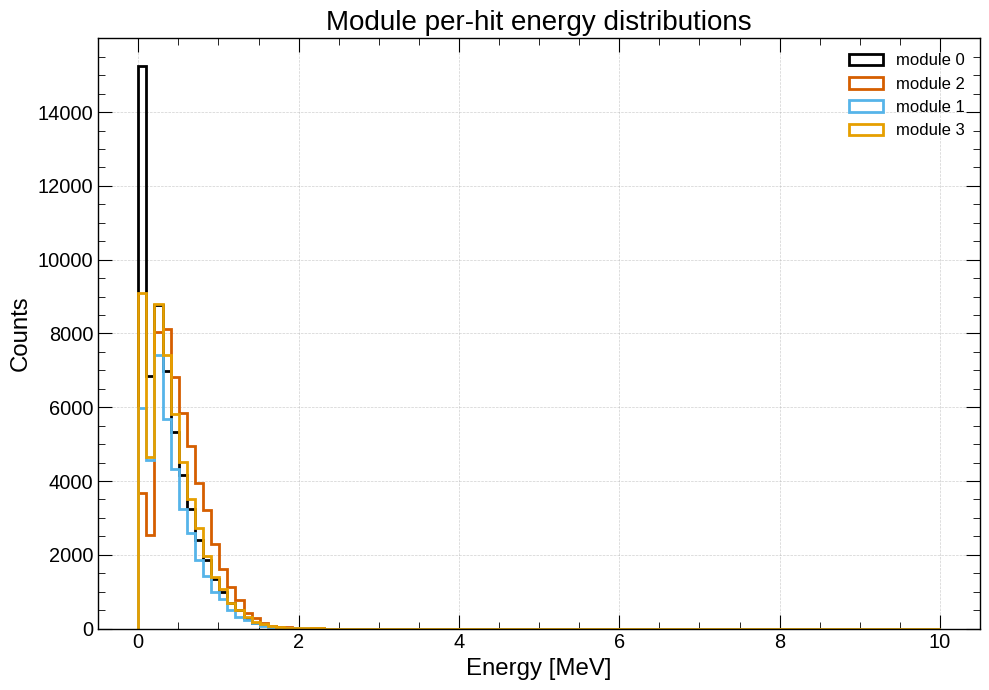

In [52]:
bins = np.linspace(0, 10.0, 100)
plt.figure(figsize=(10, 7))
for module_id, io_list in [module_map[key] for key in sorted(module_map.keys())]:
    detector_samples = [results['E_hits_io'][io_val] for io_val in io_list if io_val in results['E_hits_io']]
    if detector_samples:
        detector_values = np.concatenate(detector_samples)
        plt.hist(detector_values, bins=bins, histtype='step', linewidth=2, label=f'module {module_id}')

plt.xlabel('Energy [MeV]')
plt.ylabel('Counts')
plt.title('Module per-hit energy distributions')
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()


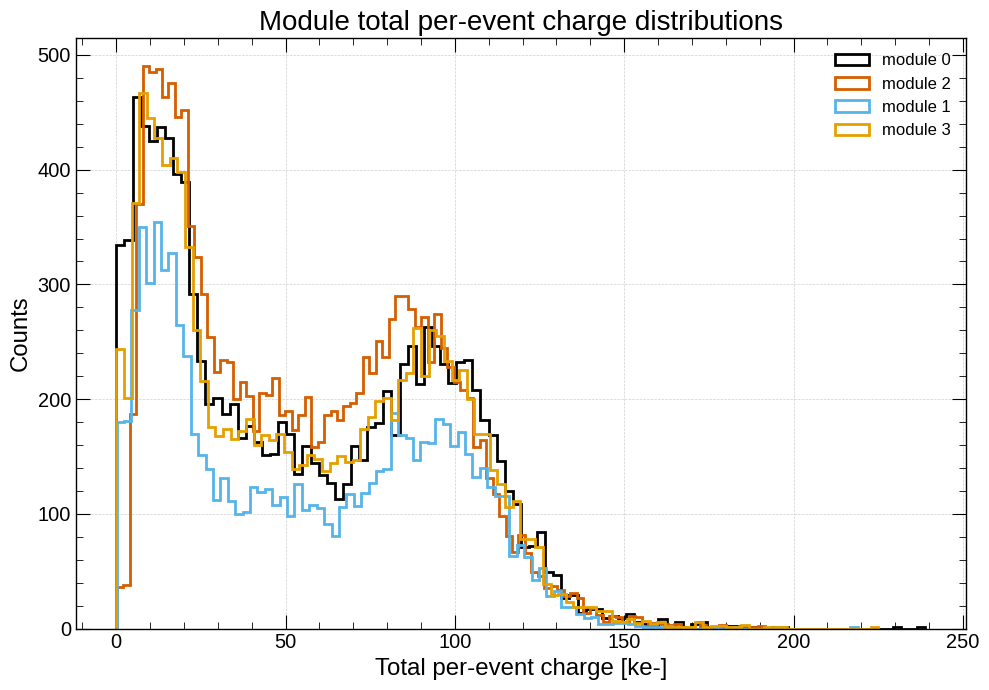

In [53]:
bins = 100
plt.figure(figsize=(10, 7))
for module_id, _ in [module_map[key] for key in sorted(module_map.keys())]:
    q_values = results['Q_event_module'].get(module_id, np.array([], dtype=np.float64))
    if len(q_values) > 0:
        plt.hist(q_values, bins=bins, histtype='step', linewidth=2, label=f'module {module_id}')

plt.xlabel('Total per-event charge [ke-]')
plt.ylabel('Counts')
plt.title('Module total per-event charge distributions')
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()


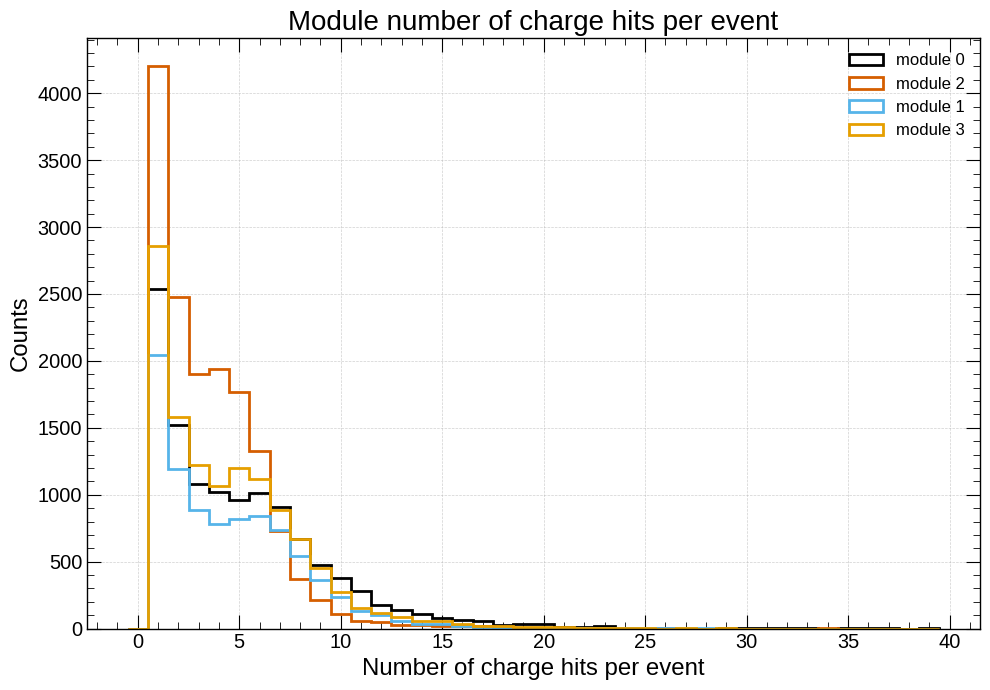

In [54]:
bins = np.arange(0, 41) - 0.5
plt.figure(figsize=(10, 7))
for module_id, _ in [module_map[key] for key in sorted(module_map.keys())]:
    n_values = results['n_hits_module'].get(module_id, np.array([], dtype=np.int64))
    if len(n_values) > 0:
        plt.hist(n_values, bins=bins, histtype='step', linewidth=2, label=f'module {module_id}')

plt.xlabel('Number of charge hits per event')
plt.ylabel('Counts')
plt.title('Module number of charge hits per event')
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()


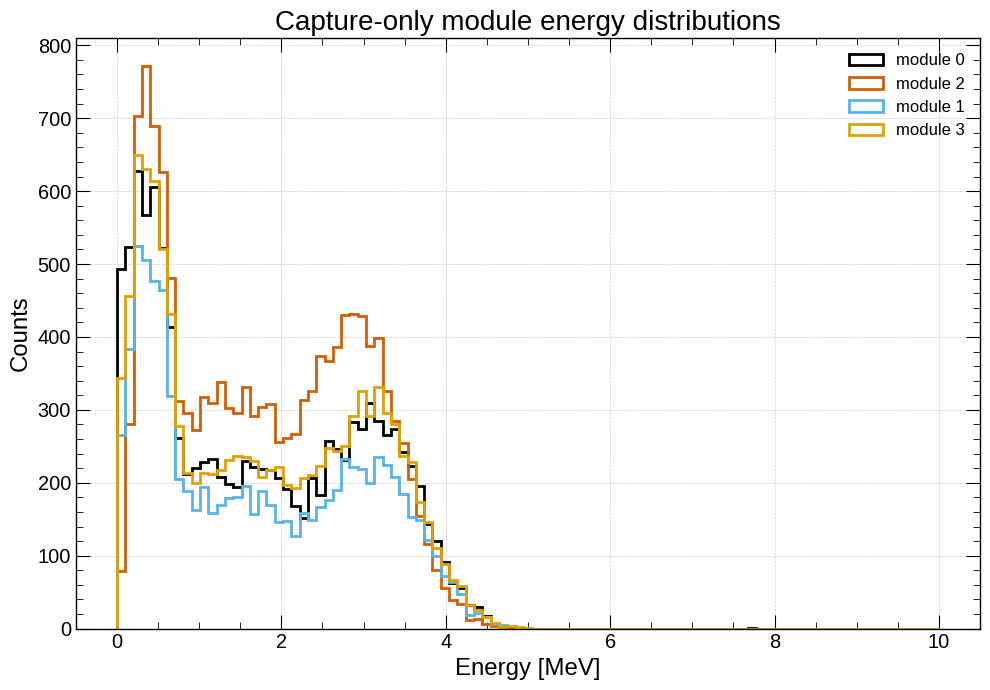

In [55]:
bins = np.linspace(0, 10.0, 100)
plt.figure(figsize=(10, 7))
for module_id, io_list in [module_map[key] for key in sorted(module_map.keys())]:
    detector_samples = [results['E_cluster_io_capture'][io_val] for io_val in io_list if io_val in results['E_cluster_io_capture']]
    if detector_samples:
        detector_values = np.concatenate(detector_samples)
        plt.hist(detector_values, bins=bins, histtype='step', linewidth=2, label=f'module {module_id}')

plt.xlabel('Energy [MeV]')
plt.ylabel('Counts')
plt.title('Capture-only module energy distributions')
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()


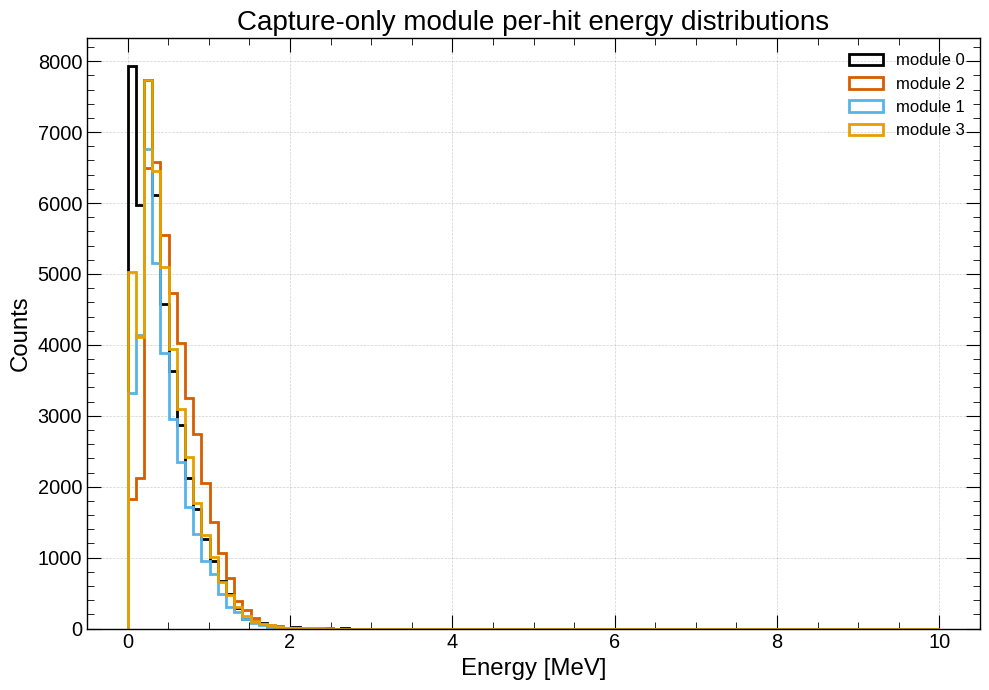

In [56]:
bins = np.linspace(0, 10.0, 100)
plt.figure(figsize=(10, 7))
for module_id, io_list in [module_map[key] for key in sorted(module_map.keys())]:
    detector_samples = [results['E_hits_io_capture'][io_val] for io_val in io_list if io_val in results['E_hits_io_capture']]
    if detector_samples:
        detector_values = np.concatenate(detector_samples)
        plt.hist(detector_values, bins=bins, histtype='step', linewidth=2, label=f'module {module_id}')

plt.xlabel('Energy [MeV]')
plt.ylabel('Counts')
plt.title('Capture-only module per-hit energy distributions')
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()


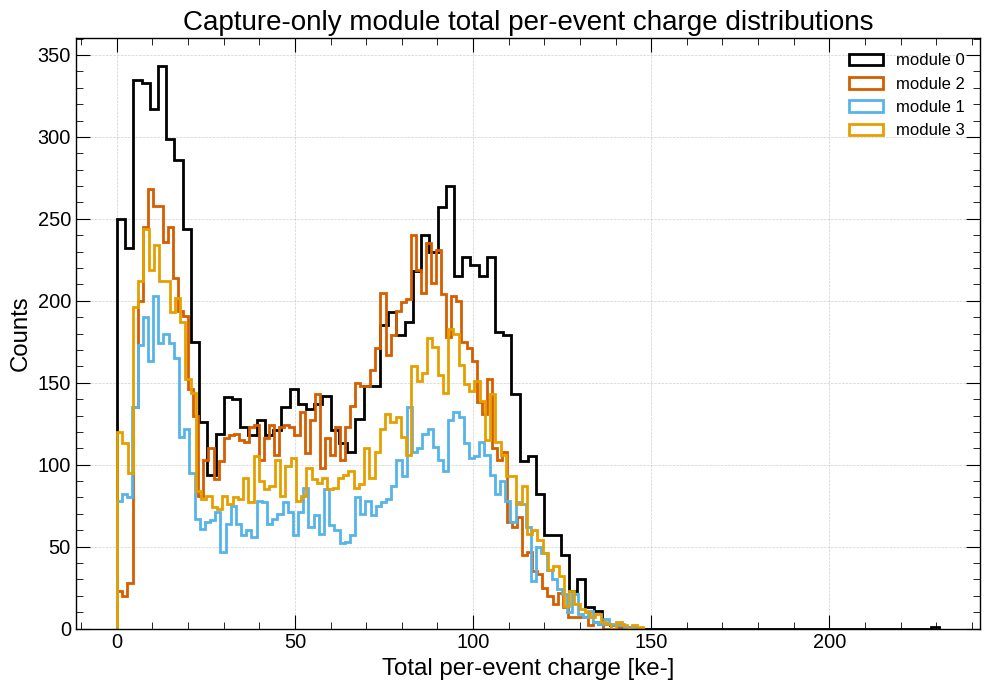

In [57]:
bins = 100
plt.figure(figsize=(10, 7))
for module_id, _ in [module_map[key] for key in sorted(module_map.keys())]:
    q_values = results['Q_event_module_capture'].get(module_id, np.array([], dtype=np.float64))
    if len(q_values) > 0:
        plt.hist(q_values, bins=bins, histtype='step', linewidth=2, label=f'module {module_id}')

plt.xlabel('Total per-event charge [ke-]')
plt.ylabel('Counts')
plt.title('Capture-only module total per-event charge distributions')
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()


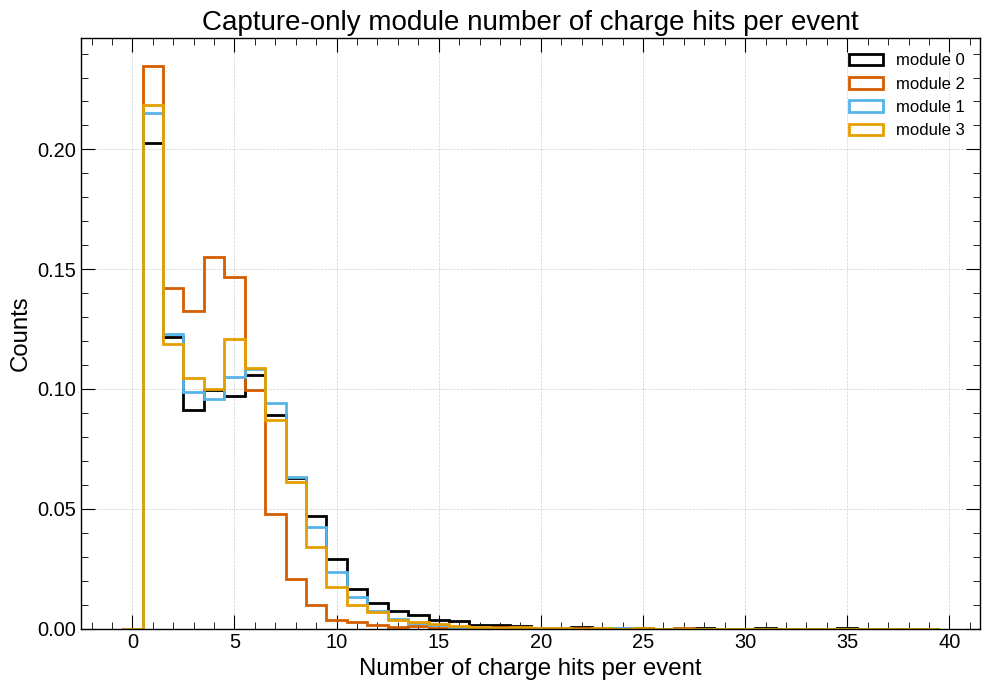

In [58]:
bins = np.arange(0, 41) - 0.5
plt.figure(figsize=(10, 7))
for module_id, _ in [module_map[key] for key in sorted(module_map.keys())]:
    n_values = results['n_hits_module_capture'].get(module_id, np.array([], dtype=np.int64))
    if len(n_values) > 0:
        plt.hist(n_values, bins=bins, histtype='step', linewidth=2, label=f'module {module_id}',density=True)

plt.xlabel('Number of charge hits per event')
plt.ylabel('Counts')
plt.title('Capture-only module number of charge hits per event')
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()


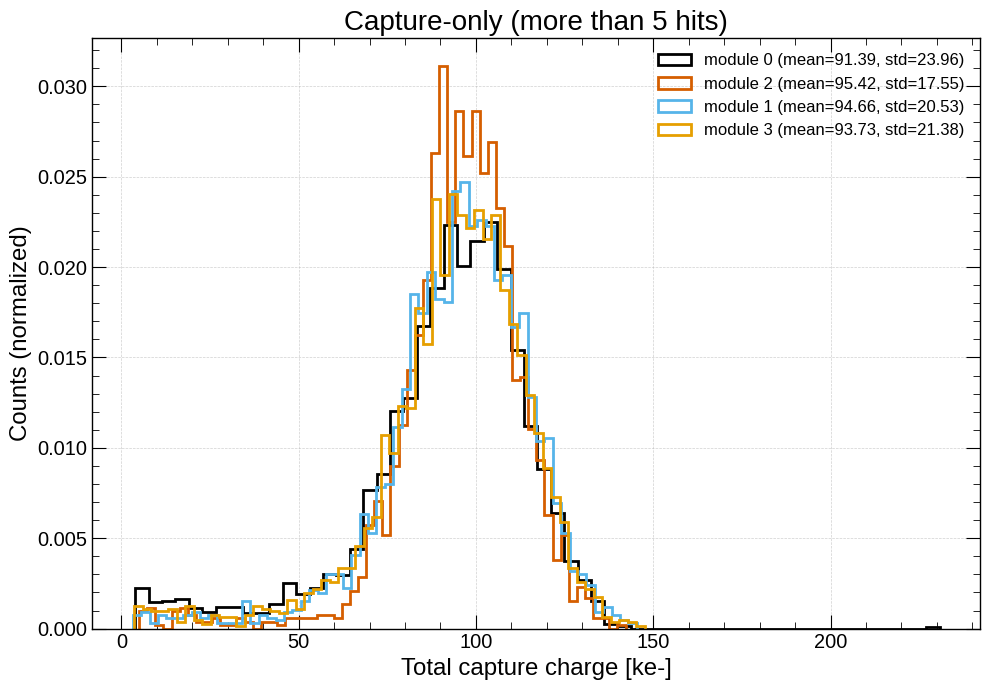

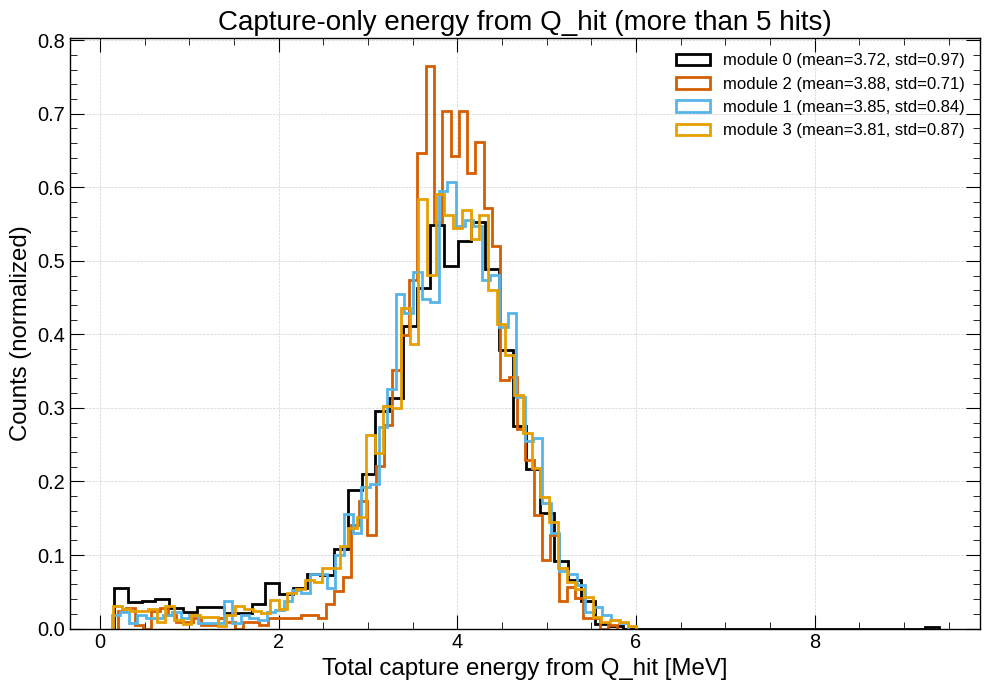

In [59]:
bins = 60
plt.figure(figsize=(10, 7))
for module_id, _ in [module_map[key] for key in sorted(module_map.keys())]:
    q_values = results['Q_event_module_capture'].get(module_id, np.array([], dtype=np.float64))
    n_values = results['n_hits_module_capture'].get(module_id, np.array([], dtype=np.int64))
    if len(q_values) > 0 and len(q_values) == len(n_values):
        mask = n_values > 5
        if np.any(mask):
            module_q = q_values[mask]
            mean_q = np.mean(module_q)
            std_q = np.std(module_q)
            label = f'module {module_id} (mean={mean_q:.2f}, std={std_q:.2f})'
            plt.hist(module_q, bins=bins, histtype='step', linewidth=2, label=label, density=True)

plt.xlabel('Total capture charge [ke-]')
plt.ylabel('Counts (normalized)')
plt.title('Capture-only (more than 5 hits)',fontsize=20)
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
for module_id, _ in [module_map[key] for key in sorted(module_map.keys())]:
    q_values = results['Q_event_module_capture'].get(module_id, np.array([], dtype=np.float64))
    n_values = results['n_hits_module_capture'].get(module_id, np.array([], dtype=np.int64))
    if len(q_values) > 0 and len(q_values) == len(n_values):
        mask = n_values > 5
        if np.any(mask):
            module_e = charge_to_energy_mev(q_values[mask])
            mean_e = np.mean(module_e)
            std_e = np.std(module_e)
            label = f'module {module_id} (mean={mean_e:.2f}, std={std_e:.2f})'
            plt.hist(module_e, bins=bins, histtype='step', linewidth=2, label=label, density=True)

plt.xlabel('Total capture energy from Q_hit [MeV]')
plt.ylabel('Counts (normalized)')
plt.title('Capture-only energy from Q_hit (more than 5 hits)', fontsize=20)
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()


In [60]:
# Optional: inspect one file quickly if a distribution looks odd.
example_file = files[0]
with h5py.File(example_file, 'r') as h5_file:
    print(f'Example file: {example_file.name}')
    print(f'Top-level keys: {list(h5_file.keys())}')
    print(f'Trajectories keys: {h5_file["mc_truth/trajectories/data"].dtype.names}')
    print(f'Segments keys: {h5_file["mc_truth/segments/data"].dtype.names}')
    print(f'Prompt hit keys: {h5_file["charge/calib_prompt_hits/data"].dtype.names}')
    print(f'Prompt hit backtrack keys: {h5_file["mc_truth/calib_prompt_hit_backtrack/data"].dtype.names}')

Example file: 2x2_QGSP_BERT_HP_AmBe_1774119367_0_TIME_MOD.FLOW.hdf5
Top-level keys: ['charge', 'combined', 'geometry_info', 'lar_info', 'light', 'mc_truth', 'run_info']
Trajectories keys: ('event_id', 'vertex_id', 'traj_id', 'file_traj_id', 'parent_id', 'primary', 'E_start', 'pxyz_start', 'xyz_start', 't_start', 'E_end', 'pxyz_end', 'xyz_end', 't_end', 'pdg_id', 'start_process', 'start_subprocess', 'end_process', 'end_subprocess', 'dist_travel')
Segments keys: ('event_id', 'vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE', 't', 'y', 'x', 'z', 'n_photons')
Prompt hit keys: ('id', 'x', 'y', 'z', 't_drift', 'ts_pps', 'io_group', 'io_channel', 'chip_id', 'channel_id', 'Q_raw', 'Q', 'E', 'is_disabled')
Prompt hit backtrack keys: ('event_ids', 'segment_ids', 'fraction', 'file_traj_ids', 'fraction_t